In [ ]:
install.packages("remotes")
remotes::install_version("Matrix", version = "1.6-5", repos = "https://cran.r-project.org")
remotes::install_version("MASS", version = "7.3-60", repos = "https://cran.r-project.org")
if (!require("BiocManager", quietly = TRUE))
    install.packages("BiocManager")

BiocManager::install("DESeq2")

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    BioCsoft: https://bioconductor.org/packages/3.20/bioc
    BioCann: https://bioconductor.org/packages/3.20/data/annotation
    BioCexp: https://bioconductor.org/packages/3.20/data/experiment
    BioCworkflows: https://bioconductor.org/packages/3.20/workflows
    BioCbooks: https://bioconductor.org/packages/3.20/books
    CRAN: https://cran.r-project.org



In [1]:
# # Example: 6 samples (3 replicates per condition), 100 genes
# counts <- matrix(rnbinom(600, mu=100, size=1/0.2), ncol=6)
# rownames(counts) <- paste0("gene", 1:100)
# colnames(counts) <- paste0("sample", 1:6)
data = read.csv(file = '/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency/data/translationEfficiency/2h_TE.csv',row.names = 1)
counts = data[,-c(1:3,7:9,13:ncol(data))]
riboseq = counts[,1:3]
rnaseq = counts[,4:6]
counts

,RPFsRawCounts.DC7_184t_bw_star_Aligned.sortedByCoord.out.bam,RPFsRawCounts.DC8_184t_bw_star_Aligned.sortedByCoord.out.bam,RPFsRawCounts.DC9_184t_bw_star_Aligned.sortedByCoord.out.bam,mRNARawCounts.DC10_184t_star_Aligned.sortedByCoord.out.bam,mRNARawCounts.DC11_184t_star_Aligned.sortedByCoord.out.bam,mRNARawCounts.DC12_184t_star_Aligned.sortedByCoord.out.bam
,<int>,<int>,<int>,<int>,<int>,<int>
FBgn0000008,21,15,9,557,525,493
FBgn0000014,8,8,2,33,45,37
FBgn0000015,1,3,1,5,22,30
FBgn0000017,298,247,234,2934,2677,2659
FBgn0000018,13,18,8,146,176,137
FBgn0000024,1,0,0,15,0,0
FBgn0000032,148,136,125,1172,1063,1151
FBgn0000039,1,0,0,2,0,0
FBgn0000042,2819,2692,2203,19793,19796,19804


In [34]:
condition <- factor(c("riboseq", "riboseq", "riboseq", "rnaseq", "rnaseq", "rnaseq"))
coldata <- data.frame(row.names=colnames(counts), condition=condition)


In [36]:
library(DESeq2)
dds <- DESeqDataSetFromMatrix(countData = counts,
                              colData = coldata,
                              design = ~ condition)


In [2]:
library(DESeq2)
coldata <- data.frame(row.names=colnames(riboseq))
ribo = DESeqDataSetFromMatrix(countData = riboseq,colData = coldata, design = ~ 1)
coldata <- data.frame(row.names=colnames(rnaseq))
rna = DESeqDataSetFromMatrix(countData = rnaseq,colData = coldata, design = ~ 1)


Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading required package: GenomicRanges

Loading required package: GenomeInfoDb

Loa

In [29]:
dds

class: DESeqDataSet 
dim: 8095 6 
metadata(1): version
assays(1): counts
rownames(8095): FBgn0000008 FBgn0000014 ... FBgn0285944 FBgn0286782
rowData names(0):
colnames(6):
  RPFsRawCounts.DC7_184t_bw_star_Aligned.sortedByCoord.out.bam
  RPFsRawCounts.DC8_184t_bw_star_Aligned.sortedByCoord.out.bam ...
  mRNARawCounts.DC11_184t_star_Aligned.sortedByCoord.out.bam
  mRNARawCounts.DC12_184t_star_Aligned.sortedByCoord.out.bam
colData names(1): condition

In [3]:
ribo = estimateSizeFactors(ribo)
ribo = estimateDispersions(ribo)
rna = estimateSizeFactors(rna)
rna = estimateDispersions(rna)


gene-wise dispersion estimates



mean-dispersion relationship

final dispersion estimates

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates



In [4]:
rowData(ribo)

DataFrame with 8095 rows and 10 columns
             baseMean    baseVar   allZero dispGeneEst dispGeneIter   dispFit
            <numeric>  <numeric> <logical>   <numeric>    <numeric> <numeric>
FBgn0000008  14.29676   11.72432     FALSE  0.00000001           17 0.3552135
FBgn0000014   5.55476    7.14528     FALSE  0.00000001            6 0.8910898
FBgn0000015   1.61645    1.00681     FALSE  0.00000001           28 3.0262866
FBgn0000017 257.28744 1018.30516     FALSE  0.01086906            7 0.0336327
FBgn0000018  12.52097   12.35091     FALSE  0.00000001            1 0.4035052
...               ...        ...       ...         ...          ...       ...
FBgn0266757   1.24092   4.619647     FALSE       1e+01           36   3.93766
FBgn0267429   0.41364   0.513294     FALSE       1e-08           27  11.78356
FBgn0267431   1.24092   4.619647     FALSE       1e+01           36   3.93766
FBgn0285944   0.41364   0.513294     FALSE       1e-08           27  11.78356
FBgn0286782   2.06820  1

In [90]:
rowData(ribo)[,'dispGeneEst']

[1] 1.000000e-08 1.000000e-08 1.000000e-08 1.086906e-02 1.000000e-08
   [6] 1.000000e-08 6.595336e-03 1.000000e-08 4.000893e-03 4.327966e-02
  [11] 2.292742e-01 6.418335e-01 6.989618e-02 2.900973e-01 1.145607e-01
  [16] 1.000000e-08 2.058658e-01 2.215705e+00 5.301160e-02 1.000000e-08
  [21] 1.000000e-08 1.499570e-01 2.736124e+00 9.532616e-02 6.205862e-02
  [26] 6.151728e-01 4.779044e-02 1.299339e-01 1.000000e-08 6.187017e-02
  [31] 2.571087e-01 7.604972e-02 1.000000e-08 3.985440e-03 1.166910e-02
  [36] 6.110599e-02 1.099552e-01 3.304680e-02 5.244195e-02 1.299056e-02
  [41] 4.594906e-01 2.306971e+00 9.528996e+00 6.111907e-02 1.000000e-08
  [46] 1.000000e-08 1.149022e-02 1.000000e-08 5.889357e-02 6.230230e-01
  [51] 1.000000e-08 3.335788e-03 3.850724e-01 1.641613e-01 4.267068e-02
  [56] 7.684685e-03 1.993706e-01 6.347586e-01 9.668465e-03 1.000000e-08
  [61] 1.000000e-08 6.832769e-02 3.276396e-01 4.374012e-02 8.939384e-02
  [66] 1.277604e-02 1.649030e-01 7.121381e-02 1.000000e-08 1.000000e-08
  [71] 1.000000e-08 1.000000e-08 4.523422e-02 1.287390e+00 9.605367e-03
  [76] 5.371418e-02 1.277223e-02 2.535583e-02 2.102464e-02 1.000000e-08
  [81] 2.184302e-02 8.268753e-03 1.000000e-08 1.000000e-08 1.000000e-08
  [86] 3.834903e-02 1.147378e-01 1.568100e+00 1.920405e-02 1.297043e+00
  [91] 1.000000e-08 2.068937e-01 1.000000e-08 2.323863e-02 8.181655e-03
  [96] 5.561549e-03 1.205705e-01 1.588483e-01 6.054902e-01 5.794041e-03
 [101] 3.686209e-03 1.177257e-01 3.310714e-02 3.610623e-02 1.097786e-03
 [106] 1.000000e-08 1.000000e-08 1.235553e+00 2.403427e-02 1.000000e-08
 [111] 1.000000e-08 6.230768e-01 5.730674e-02 2.417302e-01 1.963596e-02
 [116] 1.786172e-02 8.526051e-02 4.244815e-01 2.395334e-01 1.000000e-08
 [121] 8.356152e-02 3.915513e-02 4.241097e-02 1.496405e-01 1.000000e-08
 [126] 3.949700e-02 1.155482e-02 1.000000e-08 8.188348e-02 1.606972e-02
 [131] 8.824687e-02 1.000000e-08 5.626687e-02 2.119550e-01 1.000000e-08
 [136] 2.169663e-02 1.000000e-08 8.071631e-01 1.000000e-08 2.709944e-01
 [141] 1.000000e-08 5.296985e-03 1.232148e-01 1.668786e-01 5.885019e-02
 [146] 1.000000e-08 3.725846e-01 1.000000e-08 1.000000e-08 1.000000e-08
 [151] 1.000000e-08 1.000000e-08 1.000000e-08 1.000000e-08 1.000000e-08
 [156] 2.777461e-01 1.000000e-08 3.680289e-02 1.000000e-08 4.457172e-02
 [161] 1.726940e-02 1.000000e-08 3.408986e-02 1.000000e-08 5.807504e-02
 [166] 8.605428e-01 5.852317e-01 5.881628e-01 4.211828e-03 1.000000e-08
 [171] 8.946027e-01 3.559753e-03 2.536058e-02 9.622136e-01 1.000000e-08
 [176] 2.970834e-02 4.079090e-02 1.060767e-02 1.000000e-08 6.261739e-01
 [181] 1.839472e-02 1.000000e-08 1.907768e-02 2.423354e-02 2.873774e-02
 [186] 6.558724e-01 2.039891e-04 1.000000e-08 5.428620e-01 2.393898e-02
 [191] 1.000000e-08 1.000000e-08 1.000000e-08 3.835405e+00 1.000000e-08
 [196] 8.684675e-02 1.000000e-08 1.717344e-01 7.124732e-01 5.182740e-01
 [201] 1.000000e-08 2.205376e-01 1.000000e-08 3.993541e-02 1.000000e-08
 [206] 1.353070e-02 4.010606e-01 3.332237e-02 1.000000e-08 3.627077e-03
 [211] 1.009092e-02 6.336674e-03 2.303513e-01 2.297380e-02 1.000000e-08
 [216] 5.386607e-02 1.000000e-08 5.332070e-02 1.000000e+01 2.255173e-01
 [221] 1.000000e-08 6.438362e-02 1.099307e-01 1.196574e+00 2.820046e-01
 [226] 7.057663e-01 3.725846e-01 2.758386e-01 1.000000e-08 1.000000e-08
 [231] 1.971212e+00 1.000000e-08 1.000000e-08 2.149952e-01 1.000000e-08
 [236] 1.000000e-08 1.000000e-08 1.000000e-08 1.504972e-02 1.831143e-03
 [241] 1.709501e+00 3.817171e-03 2.160978e-01 6.227594e-01 1.703135e-01
 [246] 2.178554e-02 1.048634e-02 2.720946e-02 6.431649e-03 3.591009e-02
 [251] 5.189550e-02 8.114936e-02 2.567978e-02 7.778573e-02 3.398006e-02
 [256] 1.369035e-01 2.411412e-02 1.278561e-01 3.183955e-02 6.509143e-02
 [261] 3.350298e-01 9.904904e-03 2.464243e-01 3.963649e-02 1.000000e-08
 [266] 9.528996e+00 3.890348e-02 4.841029e-02 1.000000e-08 1.000000e-08
 [271] 1.000000e-08 1.000000e-08 4.058552e-02 4.237052e-01 2.464056e-03
 [276] 2.120430e-01 1.200107e-01 1.000000e-

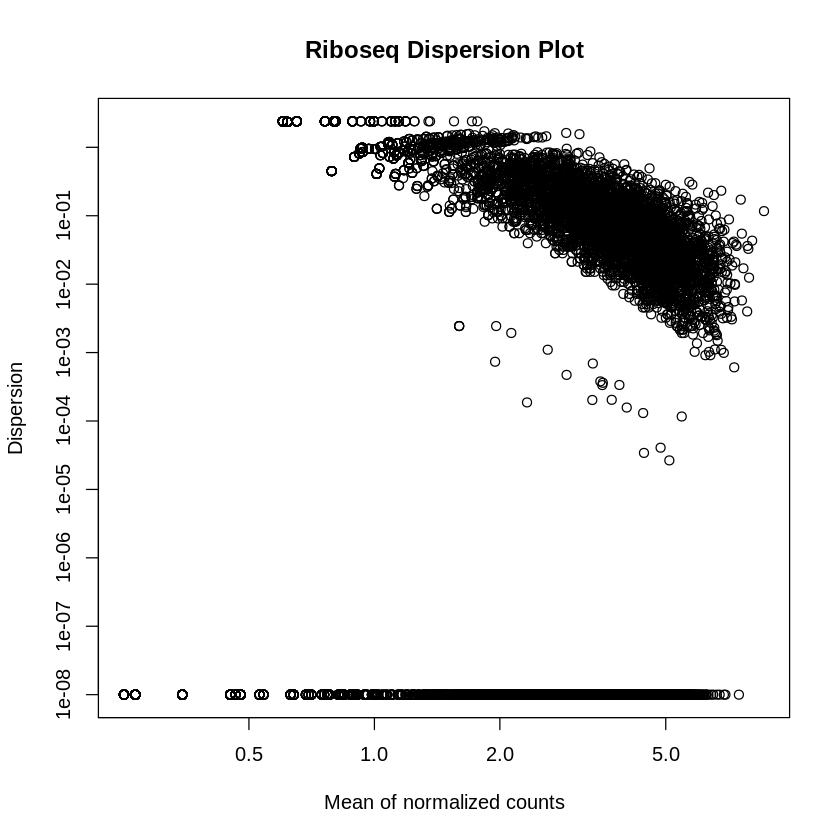

In [89]:
plot(log(rowData(ribo)[,'baseMean']+1), log(rowData(ribo)[,'dispGeneEst']+1),
     xlab = "Mean of normalized counts",
     ylab = "Dispersion",
     main = "Riboseq Dispersion Plot",log = "xy")

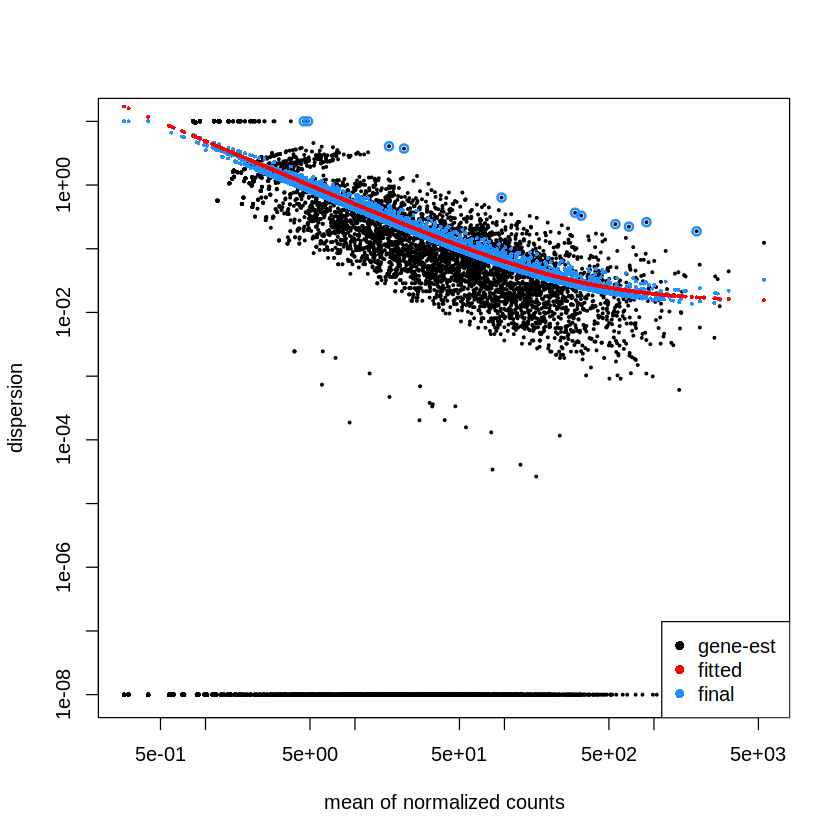

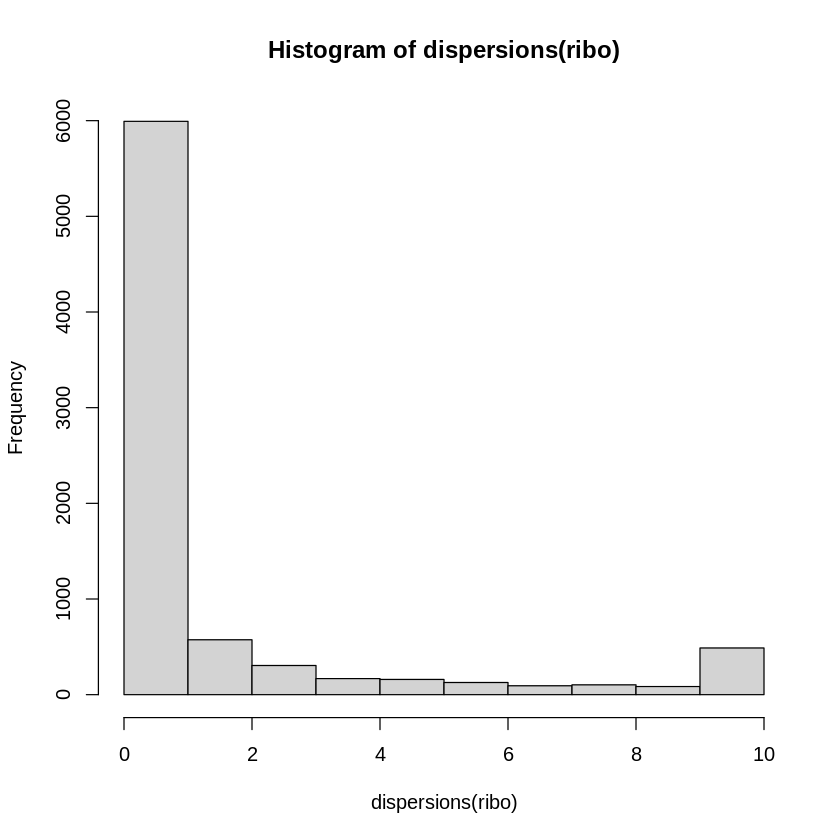

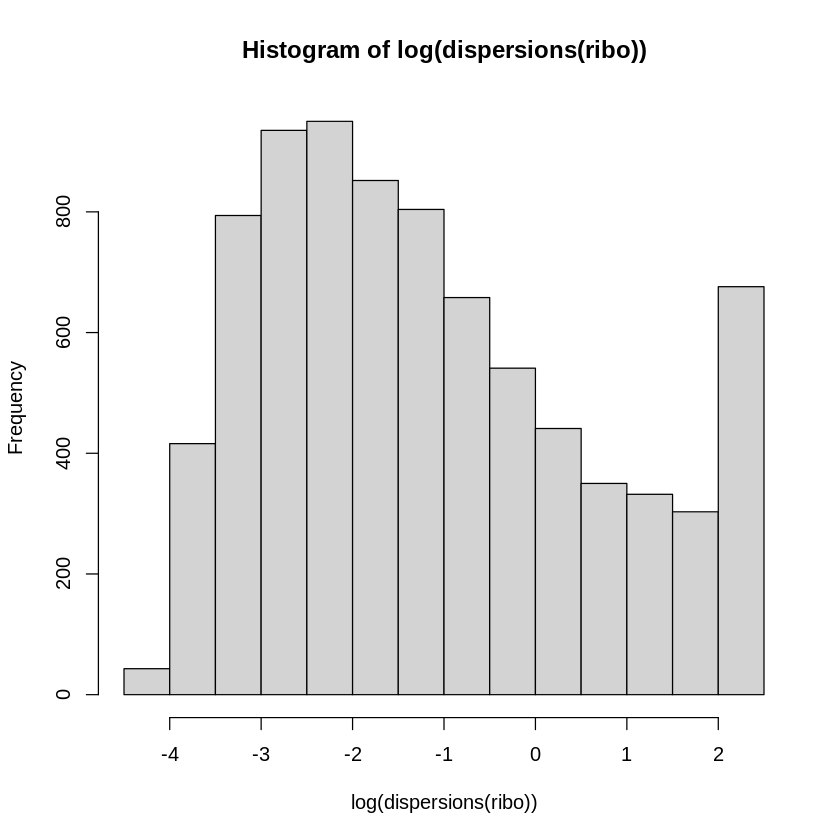

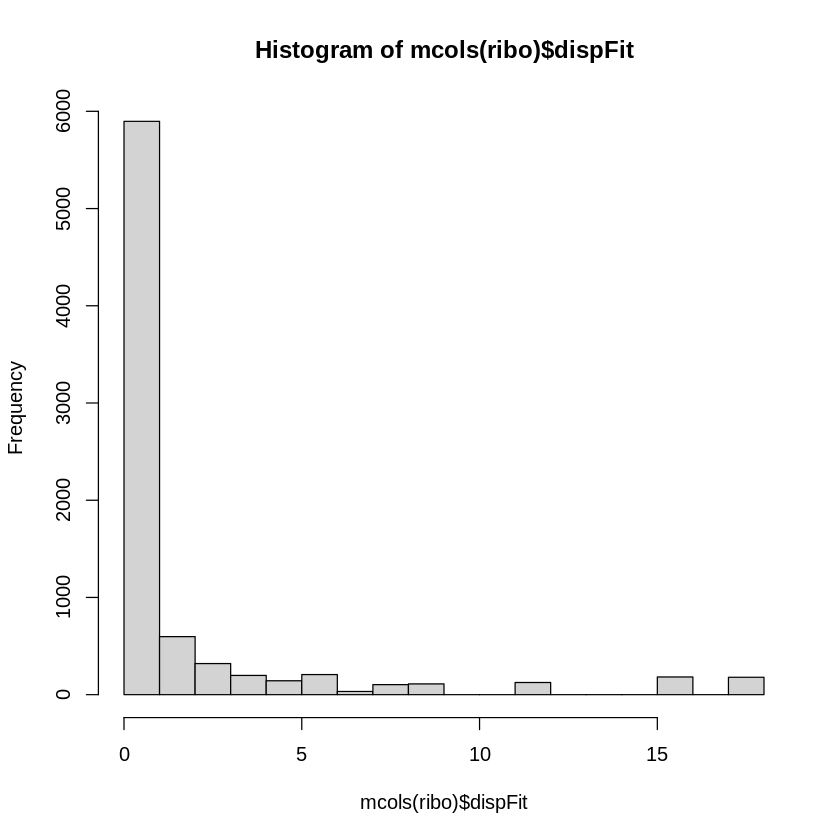

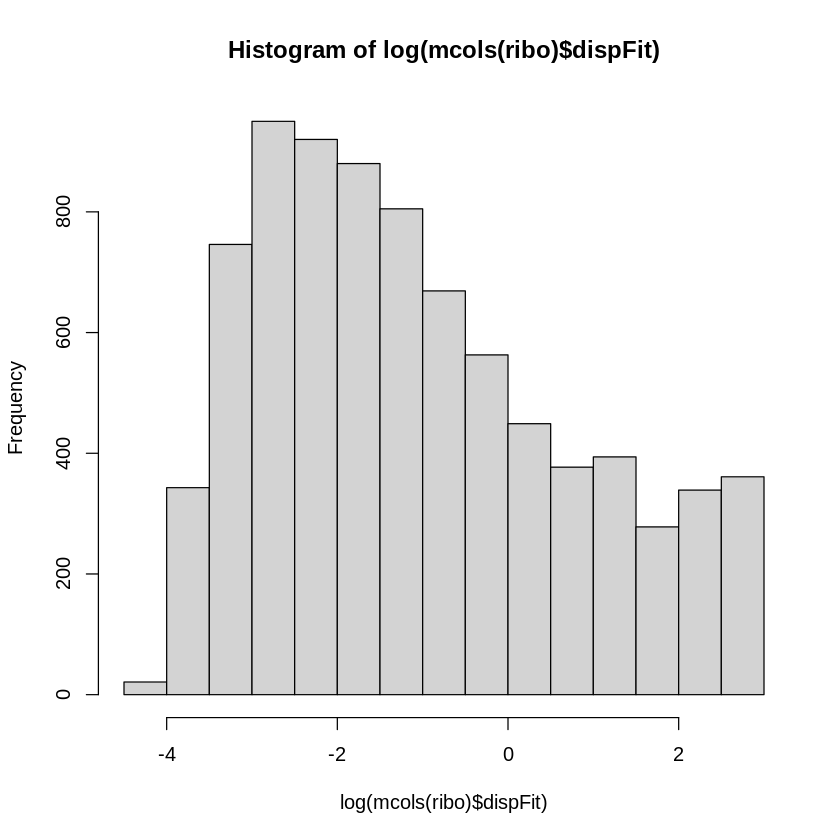

In [50]:
plotDispEsts(ribo)
hist(dispersions(ribo))
hist(log(dispersions(ribo)))
hist(mcols(ribo)$dispFit)
hist(log(mcols(ribo)$dispFit))


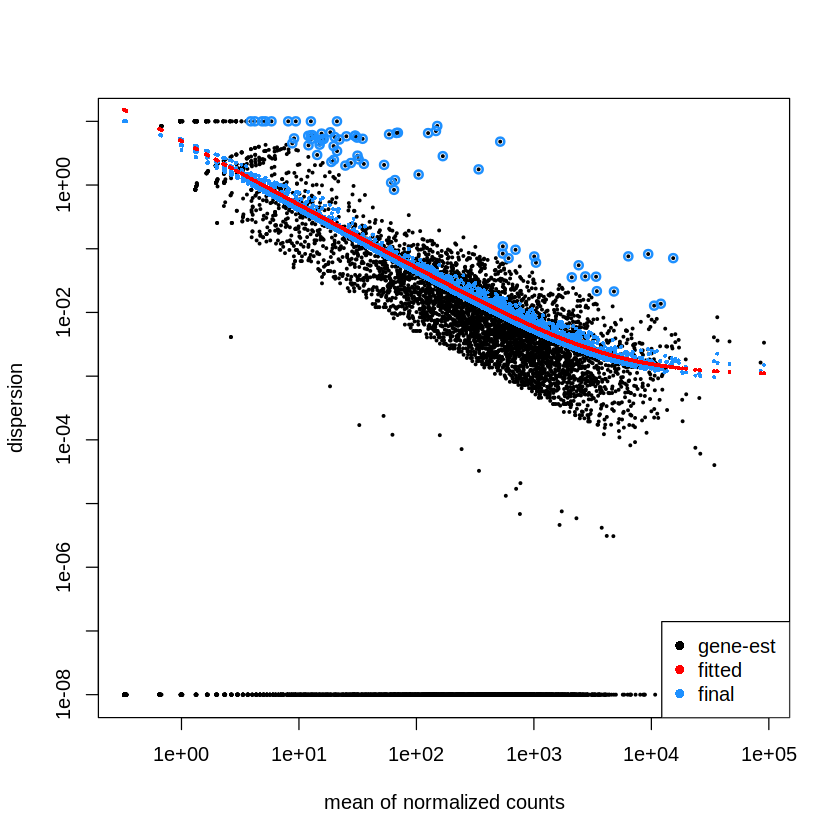

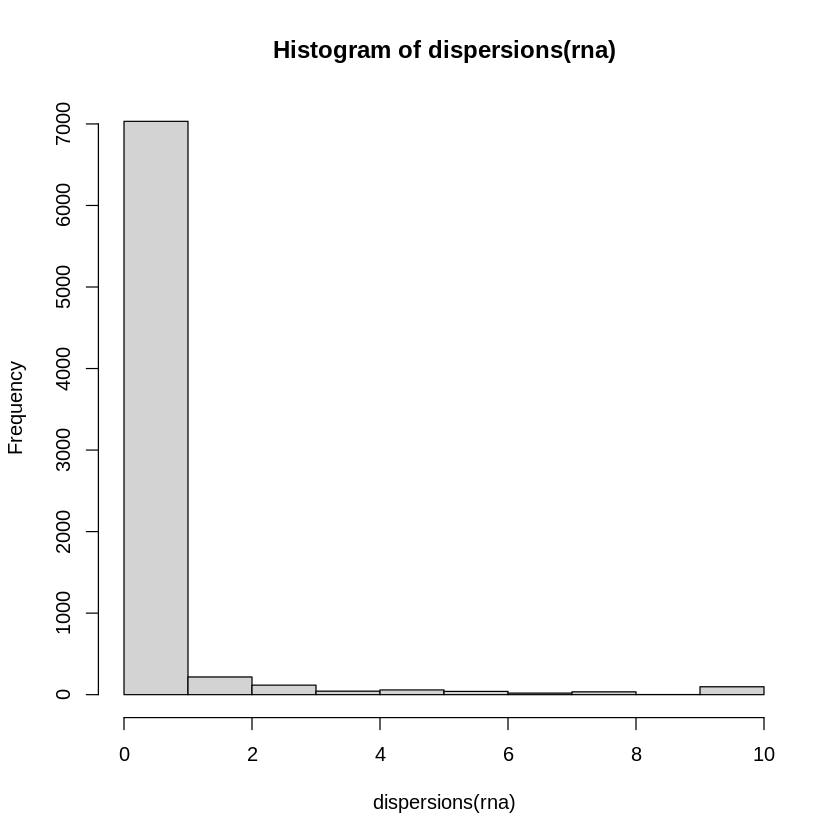

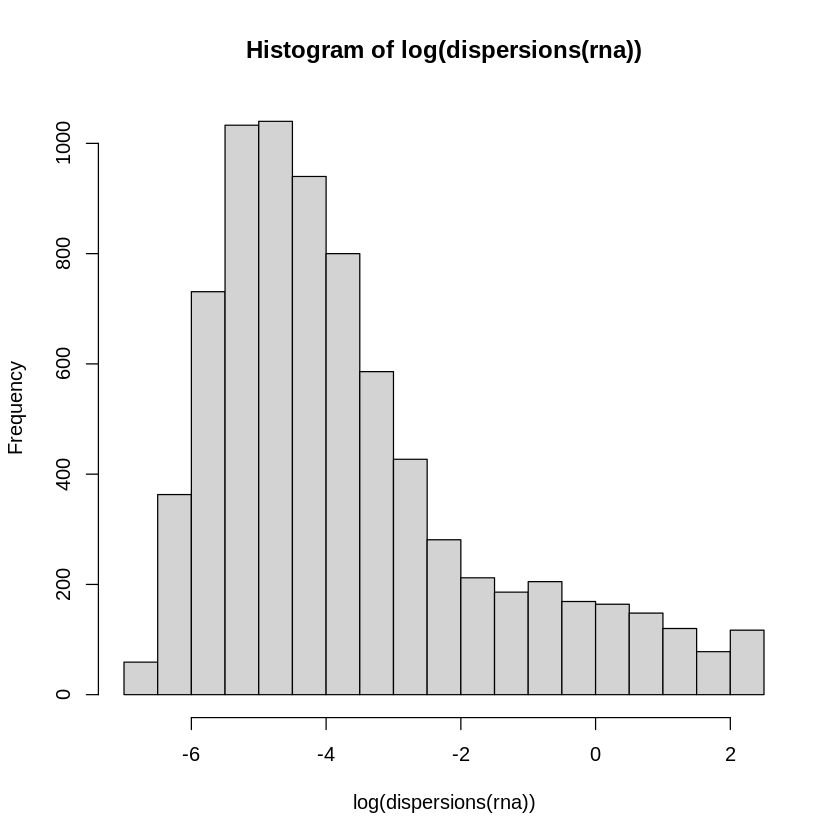

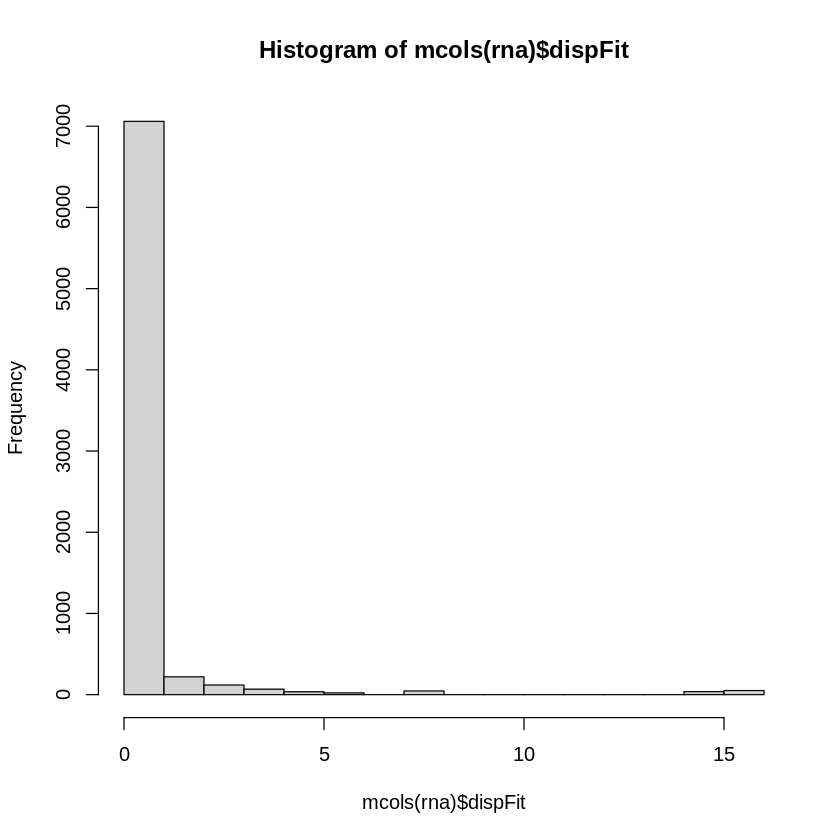

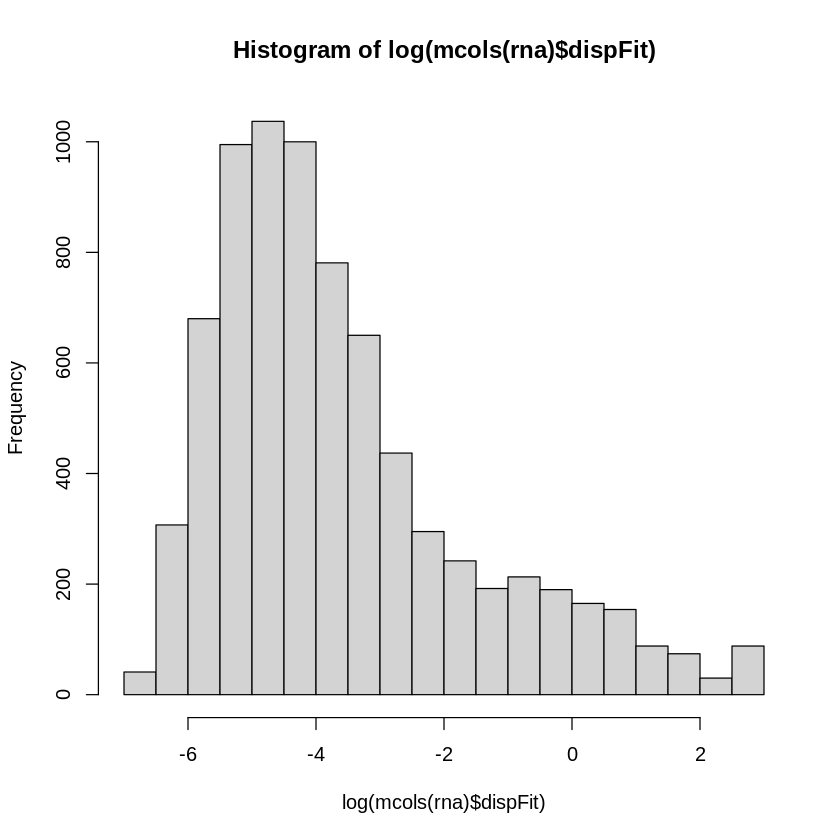

In [51]:
plotDispEsts(rna)
hist(dispersions(rna))
hist(log(dispersions(rna)))
hist(mcols(rna)$dispFit)
hist(log(mcols(rna)$dispFit))

In [55]:
sum(mcols(ribo)$dispFit < 1)
sum(na.omit(mcols(rna)$dispFit < 1))
sum(na.omit(mcols(ribo)$dispFit < 1 & mcols(rna)$dispFit < 1))

[1] 5897

[1] 7060

[1] 5680

In [5]:
sum(mcols(ribo)$dispGeneEst < 1)
sum(na.omit(mcols(rna)$dispGeneEst < 1))
sum(na.omit(mcols(ribo)$dispGeneEst < 1 & mcols(rna)$dispGeneEst < 1))

[1] 7304

[1] 7300

[1] 6699

In [57]:
sum(dispersions(ribo) < 1)
sum(na.omit(dispersions(rna) < 1))
sum(na.omit(dispersions(ribo) < 1 & dispersions(rna) < 1))

[1] 5993

[1] 7032

[1] 5753

In [ ]:
filt = dispersions(ribo) < 1 & dispersions(rna) < 1
filt[is.na(filt)] = F
dispersionPass = rownames(rowData(ribo))[filt]

filt = mcols(ribo)$dispGeneEst < 1 & mcols(rna)$dispGeneEst < 1
filt[is.na(filt)] = F
dispGeneEstPass = rownames(rowData(ribo))[filt]

dispersionPass[!dispersionPass %in% dispGeneEstPass] # genes that pass dispersion but not dispGeneEstPass
dispGeneEstPass[!dispGeneEstPass %in% dispersionPass] # genes that pass dispGeneEstPass but not dispersion

[1] "FBgn0000636" "FBgn0001114" "FBgn0001247" "FBgn0001256" "FBgn0003149"
 [6] "FBgn0003450" "FBgn0004169" "FBgn0004880" "FBgn0004885" "FBgn0010768"
[11] "FBgn0015618" "FBgn0016075" "FBgn0020445" "FBgn0026702" "FBgn0026741"
[16] "FBgn0027342" "FBgn0028402" "FBgn0029131" "FBgn0030013" "FBgn0030451"
[21] "FBgn0030600" "FBgn0030970" "FBgn0031150" "FBgn0031484" "FBgn0031608"
[26] "FBgn0032042" "FBgn0032170" "FBgn0032194" "FBgn0032259" "FBgn0032390"
[31] "FBgn0033206" "FBgn0033266" "FBgn0033275" "FBgn0033608" "FBgn0033929"
[36] "FBgn0034304" "FBgn0034573" "FBgn0034691" "FBgn0034716" "FBgn0034925"
[41] "FBgn0035158" "FBgn0035268" "FBgn0035461" "FBgn0036317" "FBgn0036381"
[46] "FBgn0036844" "FBgn0036853" "FBgn0036906" "FBgn0037087" "FBgn0037315"
[51] "FBgn0037622" "FBgn0037897" "FBgn0038017" "FBgn0038318" "FBgn0038321"
[56] "FBgn0038536" "FBgn0038972" "FBgn0039357" "FBgn0039663" "FBgn0039727"
[61] "FBgn0040079" "FBgn0040505" "FBgn0040602" "FBgn0045842" "FBgn0050392"
[66] "FBgn0052311" "FBgn0053002" "FBgn0053193" "FBgn0083961" "FBgn0085203"
[71] "FBgn0085405" "FBgn0259166" "FBgn0259676" "FBgn0260632" "FBgn0261239"
[76] "FBgn0261361" "FBgn0261436" "FBgn0263132" "FBgn0263738" "FBgn0265042"
[81] "FBgn0265605" "FBgn0266465" "FBgn0266710" "FBgn0267428" "FBgn0283471"
[86] "FBgn0288846" "FBgn0013469" "FBgn0030480" "FBgn0050001"

[1] "FBgn0000015" "FBgn0000039" "FBgn0000047" "FBgn0000108" "FBgn0000152"
   [6] "FBgn0000241" "FBgn0000274" "FBgn0000320" "FBgn0000395" "FBgn0000422"
  [11] "FBgn0000557" "FBgn0000567" "FBgn0000568" "FBgn0000591" "FBgn0000633"
  [16] "FBgn0000723" "FBgn0000826" "FBgn0000928" "FBgn0001145" "FBgn0001150"
  [21] "FBgn0001168" "FBgn0001230" "FBgn0001250" "FBgn0001255" "FBgn0001269"
  [26] "FBgn0001281" "FBgn0001291" "FBgn0001296" "FBgn0002609" "FBgn0002633"
  [31] "FBgn0002709" "FBgn0002733" "FBgn0002917" "FBgn0003074" "FBgn0003090"
  [36] "FBgn0003093" "FBgn0003145" "FBgn0003227" "FBgn0003302" "FBgn0003353"
  [41] "FBgn0003480" "FBgn0003710" "FBgn0003896" "FBgn0003950" "FBgn0004047"
  [46] "FBgn0004510" "FBgn0004513" "FBgn0004516" "FBgn0004581" "FBgn0004620"
  [51] "FBgn0004644" "FBgn0004854" "FBgn0005612" "FBgn0005677" "FBgn0008636"
  [56] "FBgn0010052" "FBgn0010317" "FBgn0010453" "FBgn0010531" "FBgn0010638"
  [61] "FBgn0010830" "FBgn0011278" "FBgn0011476" "FBgn0011591" "FBgn0011701"
  [66] "FBgn0011769" "FBgn0011828" "FBgn0013342" "FBgn0013983" "FBgn0014023"
  [71] "FBgn0014179" "FBgn0014342" "FBgn0014343" "FBgn0014464" "FBgn0014863"
  [76] "FBgn0015011" "FBgn0015025" "FBgn0015031" "FBgn0015240" "FBgn0015277"
  [81] "FBgn0015299" "FBgn0015351" "FBgn0015524" "FBgn0015561" "FBgn0015721"
  [86] "FBgn0015801" "FBgn0015829" "FBgn0016694" "FBgn0017482" "FBgn0020272"
  [91] "FBgn0020300" "FBgn0020381" "FBgn0020389" "FBgn0020493" "FBgn0020762"
  [96] "FBgn0021767" "FBgn0021875" "FBgn0022224" "FBgn0022344" "FBgn0022702"
 [101] "FBgn0022709" "FBgn0022935" "FBgn0023090" "FBgn0023181" "FBgn0023516"
 [106] "FBgn0023537" "FBgn0024194" "FBgn0024244" "FBgn0024366" "FBgn0025111"
 [111] "FBgn0025634" "FBgn0025643" "FBgn0025686" "FBgn0025702" "FBgn0025709"
 [116] "FBgn0025712" "FBgn0025742" "FBgn0025807" "FBgn0026175" "FBgn0026309"
 [121] "FBgn0026315" "FBgn0026393" "FBgn0027093" "FBgn0027106" "FBgn0027343"
 [126] "FBgn0027570" "FBgn0028382" "FBgn0028494" "FBgn0028499" "FBgn0028525"
 [131] "FBgn0028527" "FBgn0028645" "FBgn0028648" "FBgn0028663" "FBgn0028707"
 [136] "FBgn0028789" "FBgn0028862" "FBgn0028897" "FBgn0028979" "FBgn0028983"
 [141] "FBgn0029167" "FBgn0029508" "FBgn0029712" "FBgn0029737" "FBgn0029753"
 [146] "FBgn0029754" "FBgn0029771" "FBgn0029857" "FBgn0029890" "FBgn0029892"
 [151] "FBgn0029894" "FBgn0029906" "FBgn0029939" "FBgn0029940" "FBgn0029958"
 [156] "FBgn0030001" "FBgn0030008" "FBgn0030012" "FBgn0030017" "FBgn0030026"
 [161] "FBgn0030039" "FBgn0030085" "FBgn0030092" "FBgn0030101" "FBgn0030159"
 [166] "FBgn0030174" "FBgn0030187" "FBgn0030242" "FBgn0030361" "FBgn0030396"
 [171] "FBgn0030411" "FBgn0030482" "FBgn0030528" "FBgn0030552" "FBgn0030572"
 [176] "FBgn0030598" "FBgn0030640" "FBgn0030642" "FBgn0030659" "FBgn0030660"
 [181] "FBgn0030671" "FBgn0030676" "FBgn0030695" "FBgn0030716" "FBgn0030759"
 [186] "FBgn0030764" "FBgn0030793" "FBgn0030794" "FBgn0030801" "FBgn0030815"
 [191] "FBgn0030839" "FBgn0030868" "FBgn0030883" "FBgn0030918" "FBgn0030975"
 [196] "FBgn0031003" "FBgn0031060" "FBgn0031068" "FBgn0031091" "FBgn0031092"
 [201] "FBgn0031099" "FBgn0031189" "FBgn0031227" "FBgn0031239" "FBgn0031245"
 [206] "FBgn0031247" "FBgn0031250" "FBgn0031263" "FBgn0031265" "FBgn0031267"
 [211] "FBgn0031286" "FBgn0031296" "FBgn0031344" "FBgn0031365" "FBgn0031379"
 [216] "FBgn0031403" "FBgn0031422" "FBgn0031428" "FBgn0031496" "FBgn0031534"
 [221] "FBgn0031571" "FBgn0031575" "FBgn0031630" "FBgn0031634" "FBgn0031637"
 [226] "FBgn0031644" "FBgn0031646" "FBgn0031676" "FBgn0031766" "FBgn0031774"
 [231] "FBgn0031834" "FBgn0031849" "FBgn0031856" "FBgn0031869" "FBgn0031877"
 [236] "FBgn0031894" "FBgn0031914" "FBgn0031948" "FBgn0031959" "FBgn0031987"
 [241] "FBgn0031992" "FBgn0031999" "FBgn0032006" "FBgn0032031" "FBgn0032047"
 [246] "FBgn0032076" "FBgn0032153" "FBgn0032154" "FBgn0032171" "FBgn0032249"
 [251] "FBgn0032261" "FBgn0032284" "FBgn0032330" "FBgn0032343" "FBgn0032393"
 [256] "FBgn0032404" "FBgn0032446" "FBgn0032449" "FBgn0032483" "FBgn0032629"

In [24]:
filt = apply(counts, 1, function(x) sum(x >= 1))
filt = unlist(filt) == 6
countsPass = rownames(counts)[filt]

dispersionPass[!dispersionPass %in% countsPass] # genes that pass dispersion but not dispGeneEstPass
countsPass[!countsPass %in% dispersionPass] # genes that pass dispGeneEstPass but not dispersion
intersect(countsPass[!countsPass %in% dispersionPass],dispGeneEstPass[!dispGeneEstPass %in% dispersionPass])

[1] "FBgn0001114" "FBgn0003149" "FBgn0003450" "FBgn0004880" "FBgn0010768"
 [6] "FBgn0028402" "FBgn0030013" "FBgn0030600" "FBgn0031150" "FBgn0032042"
[11] "FBgn0032194" "FBgn0032259" "FBgn0033206" "FBgn0033266" "FBgn0033929"
[16] "FBgn0034304" "FBgn0034716" "FBgn0034925" "FBgn0035158" "FBgn0035268"
[21] "FBgn0036381" "FBgn0036906" "FBgn0038017" "FBgn0038972" "FBgn0039357"
[26] "FBgn0039727" "FBgn0053193" "FBgn0085203" "FBgn0261436" "FBgn0263132"
[31] "FBgn0265605" "FBgn0283471" "FBgn0288846" "FBgn0013469" "FBgn0030480"
[36] "FBgn0050001"

[1] "FBgn0000015" "FBgn0000044" "FBgn0000047" "FBgn0000108" "FBgn0000152"
  [6] "FBgn0000299" "FBgn0000320" "FBgn0000395" "FBgn0000591" "FBgn0000723"
 [11] "FBgn0000826" "FBgn0000928" "FBgn0001150" "FBgn0001168" "FBgn0001230"
 [16] "FBgn0001250" "FBgn0001253" "FBgn0001291" "FBgn0002633" "FBgn0002709"
 [21] "FBgn0003074" "FBgn0003093" "FBgn0003137" "FBgn0003145" "FBgn0003227"
 [26] "FBgn0003302" "FBgn0003480" "FBgn0003710" "FBgn0003896" "FBgn0003944"
 [31] "FBgn0005612" "FBgn0005666" "FBgn0010531" "FBgn0010638" "FBgn0010830"
 [36] "FBgn0011476" "FBgn0011769" "FBgn0011828" "FBgn0013435" "FBgn0014023"
 [41] "FBgn0014342" "FBgn0014343" "FBgn0015011" "FBgn0015031" "FBgn0015240"
 [46] "FBgn0015919" "FBgn0016694" "FBgn0020272" "FBgn0020300" "FBgn0020381"
 [51] "FBgn0021875" "FBgn0022224" "FBgn0022344" "FBgn0022935" "FBgn0023537"
 [56] "FBgn0024194" "FBgn0024366" "FBgn0025111" "FBgn0025702" "FBgn0025712"
 [61] "FBgn0025742" "FBgn0025807" "FBgn0026315" "FBgn0026393" "FBgn0027093"
 [66] "FBgn0027106" "FBgn0027527" "FBgn0028382" "FBgn0028499" "FBgn0028645"
 [71] "FBgn0028648" "FBgn0028707" "FBgn0028789" "FBgn0028897" "FBgn0029737"
 [76] "FBgn0029857" "FBgn0029874" "FBgn0029894" "FBgn0029906" "FBgn0029939"
 [81] "FBgn0030012" "FBgn0030026" "FBgn0030092" "FBgn0030101" "FBgn0030174"
 [86] "FBgn0030187" "FBgn0030242" "FBgn0030361" "FBgn0030396" "FBgn0030482"
 [91] "FBgn0030528" "FBgn0030552" "FBgn0030572" "FBgn0030640" "FBgn0030660"
 [96] "FBgn0030671" "FBgn0030676" "FBgn0030716" "FBgn0030793" "FBgn0030801"
[101] "FBgn0030839" "FBgn0030868" "FBgn0030883" "FBgn0031091" "FBgn0031092"
[106] "FBgn0031189" "FBgn0031227" "FBgn0031239" "FBgn0031245" "FBgn0031247"
[111] "FBgn0031250" "FBgn0031265" "FBgn0031267" "FBgn0031286" "FBgn0031296"
[116] "FBgn0031344" "FBgn0031379" "FBgn0031534" "FBgn0031575" "FBgn0031766"
[121] "FBgn0031774" "FBgn0031877" "FBgn0031959" "FBgn0031987" "FBgn0031992"
[126] "FBgn0032006" "FBgn0032153" "FBgn0032154" "FBgn0032249" "FBgn0032261"
[131] "FBgn0032343" "FBgn0032393" "FBgn0032446" "FBgn0032449" "FBgn0032629"
[136] "FBgn0032682" "FBgn0032683" "FBgn0032730" "FBgn0032750" "FBgn0032779"
[141] "FBgn0032801" "FBgn0032813" "FBgn0033033" "FBgn0033088" "FBgn0033174"
[146] "FBgn0033186" "FBgn0033188" "FBgn0033191" "FBgn0033259" "FBgn0033340"
[151] "FBgn0033426" "FBgn0033429" "FBgn0033451" "FBgn0033468" "FBgn0033538"
[156] "FBgn0033549" "FBgn0033616" "FBgn0033748" "FBgn0033749" "FBgn0033799"
[161] "FBgn0033836" "FBgn0033906" "FBgn0033945" "FBgn0033960" "FBgn0033973"
[166] "FBgn0033982" "FBgn0033994" "FBgn0034029" "FBgn0034033" "FBgn0034191"
[171] "FBgn0034224" "FBgn0034264" "FBgn0034265" "FBgn0034266" "FBgn0034356"
[176] "FBgn0034408" "FBgn0034442" "FBgn0034476" "FBgn0034500" "FBgn0034585"
[181] "FBgn0034602" "FBgn0034626" "FBgn0034938" "FBgn0034958" "FBgn0035101"
[186] "FBgn0035146" "FBgn0035153" "FBgn0035169" "FBgn0035189" "FBgn0035203"
[191] "FBgn0035295" "FBgn0035309" "FBgn0035407" "FBgn0035435" "FBgn0035475"
[196] "FBgn0035522" "FBgn0035529" "FBgn0035540" "FBgn0035760" "FBgn0035811"
[201] "FBgn0035999" "FBgn0036028" "FBgn0036198" "FBgn0036240" "FBgn0036350"
[206] "FBgn0036463" "FBgn0036772" "FBgn0036773" "FBgn0036795" "FBgn0036843"
[211] "FBgn0036893" "FBgn0036922" "FBgn0036999" "FBgn0037045" "FBgn0037076"
[216] "FBgn0037092" "FBgn0037105" "FBgn0037203" "FBgn0037251" "FBgn0037473"
[221] "FBgn0037518" "FBgn0037526" "FBgn0037531" "FBgn0037661" "FBgn0037777"
[226] "FBgn0037781" "FBgn0037816" "FBgn0037852" "FBgn0037879" "FBgn0037889"
[231] "FBgn0037890" "FBgn0037898" "FBgn0037902" "FBgn0038039" "FBgn0038043"
[236] "FBgn0038080" "FBgn0038128" "FBgn0038183" "FBgn0038194" "FBgn0038206"
[241] "FBgn0038247" "FBgn0038418" "FBgn0038455" "FBgn0038545" "FBgn0038577"
[246] "FBgn0038586" "FBgn0038590" "FBgn0038619" "FBgn0038638" "FBgn0038744"
[251] "FBgn0038769" "FBgn0038830" "FBgn0038861" "FBgn0038869" "FBgn0038889"
[256] "FBgn0038981" "FBgn0039020" "FBgn0039135" "FBgn0039167" "FBgn0039175"
[261] "FBgn0039257" "FBgn0039273" "FBgn0039639" "F

[1] "FBgn0000015" "FBgn0000047" "FBgn0000108" "FBgn0000152" "FBgn0000320"
  [6] "FBgn0000395" "FBgn0000591" "FBgn0000723" "FBgn0000826" "FBgn0000928"
 [11] "FBgn0001150" "FBgn0001168" "FBgn0001230" "FBgn0001250" "FBgn0001291"
 [16] "FBgn0002633" "FBgn0002709" "FBgn0003074" "FBgn0003093" "FBgn0003145"
 [21] "FBgn0003227" "FBgn0003302" "FBgn0003480" "FBgn0003710" "FBgn0003896"
 [26] "FBgn0005612" "FBgn0010531" "FBgn0010638" "FBgn0010830" "FBgn0011476"
 [31] "FBgn0011769" "FBgn0011828" "FBgn0014023" "FBgn0014342" "FBgn0014343"
 [36] "FBgn0015011" "FBgn0015031" "FBgn0015240" "FBgn0016694" "FBgn0020272"
 [41] "FBgn0020300" "FBgn0020381" "FBgn0021875" "FBgn0022224" "FBgn0022344"
 [46] "FBgn0022935" "FBgn0023537" "FBgn0024194" "FBgn0024366" "FBgn0025111"
 [51] "FBgn0025702" "FBgn0025712" "FBgn0025742" "FBgn0025807" "FBgn0026315"
 [56] "FBgn0026393" "FBgn0027093" "FBgn0027106" "FBgn0028382" "FBgn0028499"
 [61] "FBgn0028645" "FBgn0028648" "FBgn0028707" "FBgn0028789" "FBgn0028897"
 [66] "FBgn0029737" "FBgn0029857" "FBgn0029894" "FBgn0029906" "FBgn0029939"
 [71] "FBgn0030012" "FBgn0030026" "FBgn0030092" "FBgn0030101" "FBgn0030174"
 [76] "FBgn0030187" "FBgn0030242" "FBgn0030361" "FBgn0030396" "FBgn0030482"
 [81] "FBgn0030528" "FBgn0030552" "FBgn0030572" "FBgn0030640" "FBgn0030660"
 [86] "FBgn0030671" "FBgn0030676" "FBgn0030716" "FBgn0030793" "FBgn0030801"
 [91] "FBgn0030839" "FBgn0030868" "FBgn0030883" "FBgn0031091" "FBgn0031092"
 [96] "FBgn0031189" "FBgn0031227" "FBgn0031239" "FBgn0031245" "FBgn0031247"
[101] "FBgn0031250" "FBgn0031265" "FBgn0031267" "FBgn0031286" "FBgn0031296"
[106] "FBgn0031344" "FBgn0031379" "FBgn0031534" "FBgn0031575" "FBgn0031766"
[111] "FBgn0031774" "FBgn0031877" "FBgn0031959" "FBgn0031987" "FBgn0031992"
[116] "FBgn0032006" "FBgn0032153" "FBgn0032154" "FBgn0032249" "FBgn0032261"
[121] "FBgn0032343" "FBgn0032393" "FBgn0032446" "FBgn0032449" "FBgn0032629"
[126] "FBgn0032682" "FBgn0032683" "FBgn0032730" "FBgn0032750" "FBgn0032779"
[131] "FBgn0032801" "FBgn0032813" "FBgn0033033" "FBgn0033088" "FBgn0033174"
[136] "FBgn0033186" "FBgn0033188" "FBgn0033191" "FBgn0033259" "FBgn0033340"
[141] "FBgn0033426" "FBgn0033451" "FBgn0033468" "FBgn0033538" "FBgn0033549"
[146] "FBgn0033616" "FBgn0033748" "FBgn0033749" "FBgn0033799" "FBgn0033836"
[151] "FBgn0033906" "FBgn0033945" "FBgn0033960" "FBgn0033973" "FBgn0033982"
[156] "FBgn0033994" "FBgn0034029" "FBgn0034033" "FBgn0034191" "FBgn0034224"
[161] "FBgn0034264" "FBgn0034265" "FBgn0034266" "FBgn0034356" "FBgn0034408"
[166] "FBgn0034442" "FBgn0034476" "FBgn0034500" "FBgn0034585" "FBgn0034602"
[171] "FBgn0034626" "FBgn0034938" "FBgn0034958" "FBgn0035101" "FBgn0035146"
[176] "FBgn0035153" "FBgn0035169" "FBgn0035189" "FBgn0035203" "FBgn0035295"
[181] "FBgn0035309" "FBgn0035407" "FBgn0035435" "FBgn0035522" "FBgn0035529"
[186] "FBgn0035540" "FBgn0035760" "FBgn0035811" "FBgn0035999" "FBgn0036028"
[191] "FBgn0036198" "FBgn0036240" "FBgn0036350" "FBgn0036463" "FBgn0036772"
[196] "FBgn0036773" "FBgn0036795" "FBgn0036843" "FBgn0036893" "FBgn0036922"
[201] "FBgn0036999" "FBgn0037045" "FBgn0037092" "FBgn0037105" "FBgn0037203"
[206] "FBgn0037251" "FBgn0037473" "FBgn0037518" "FBgn0037526" "FBgn0037531"
[211] "FBgn0037661" "FBgn0037777" "FBgn0037781" "FBgn0037816" "FBgn0037852"
[216] "FBgn0037879" "FBgn0037889" "FBgn0037890" "FBgn0037898" "FBgn0037902"
[221] "FBgn0038039" "FBgn0038043" "FBgn0038080" "FBgn0038128" "FBgn0038183"
[226] "FBgn0038194" "FBgn0038206" "FBgn0038247" "FBgn0038418" "FBgn0038455"
[231] "FBgn0038545" "FBgn0038577" "FBgn0038586" "FBgn0038590" "FBgn0038619"
[236] "FBgn0038638" "FBgn0038744" "FBgn0038769" "FBgn0038830" "FBgn0038861"
[241] "FBgn0038869" "FBgn0038981" "FBgn0039020" "FBgn0039135" "FBgn0039167"
[246] "FBgn0039175" "FBgn0039273" "FBgn0039639" "FBgn0039641" "FBgn0039709"
[251] "FBgn0039731" "FBgn0039776" "FBgn0039881" "FBgn0039886" "FBgn0040070"
[256] "FBgn0040153" "FBgn0040207" "FBgn0040259" "FBgn0040297" "FBgn0040323"
[261] "FBgn0040336" "FBgn0040370" "FBgn0040384" "F

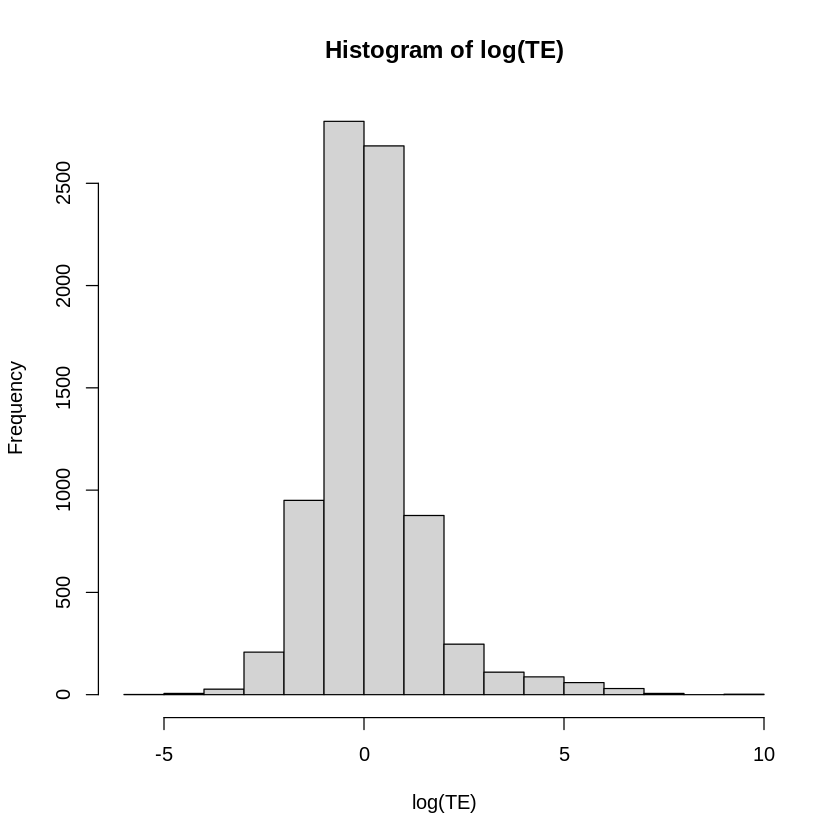

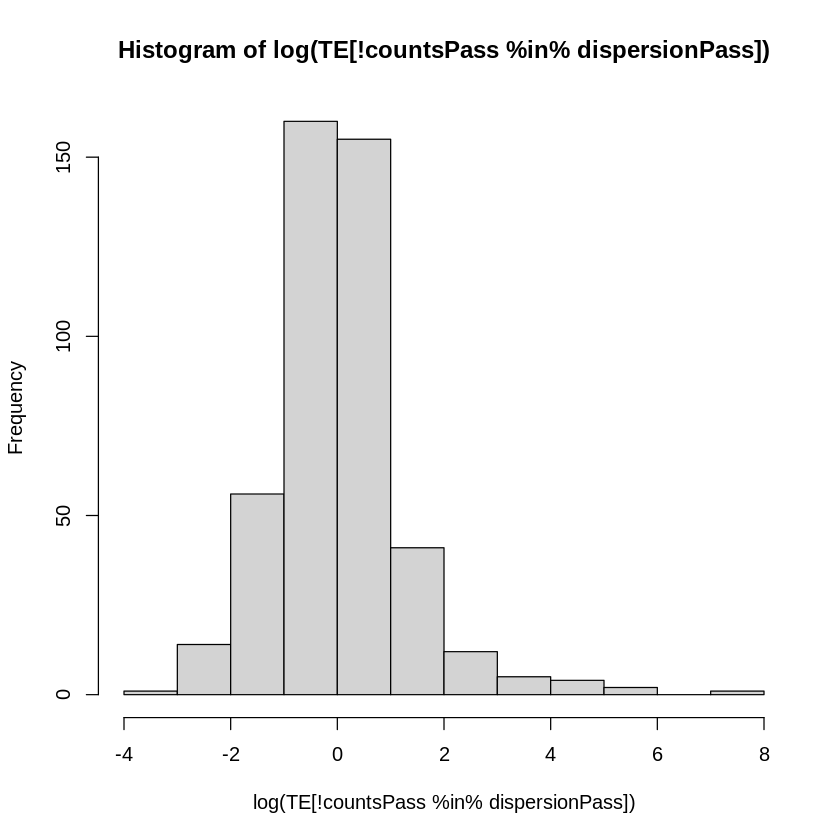

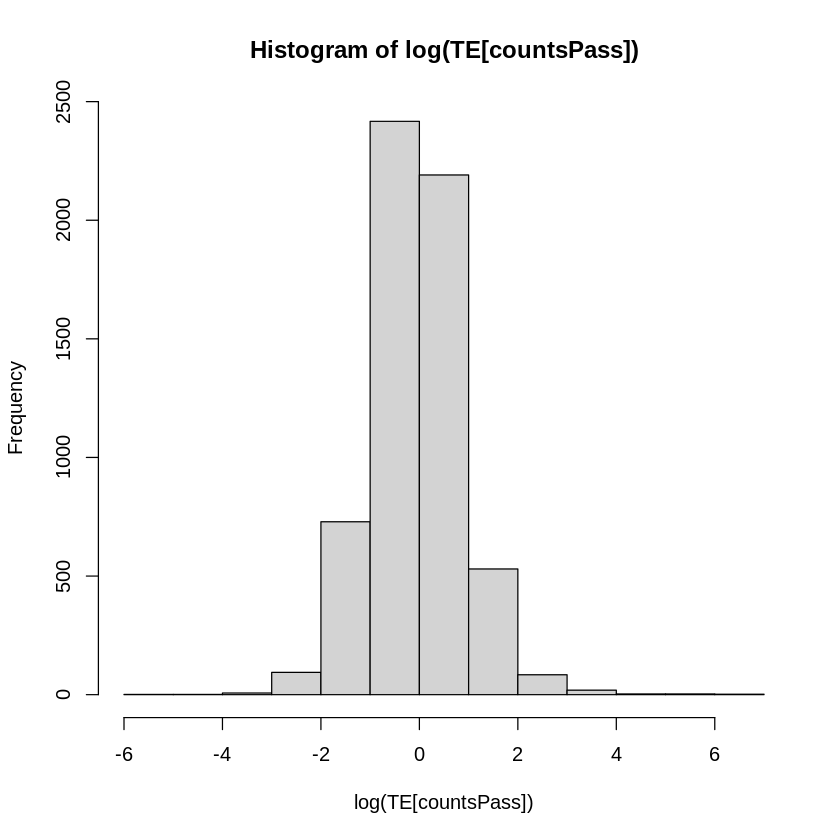

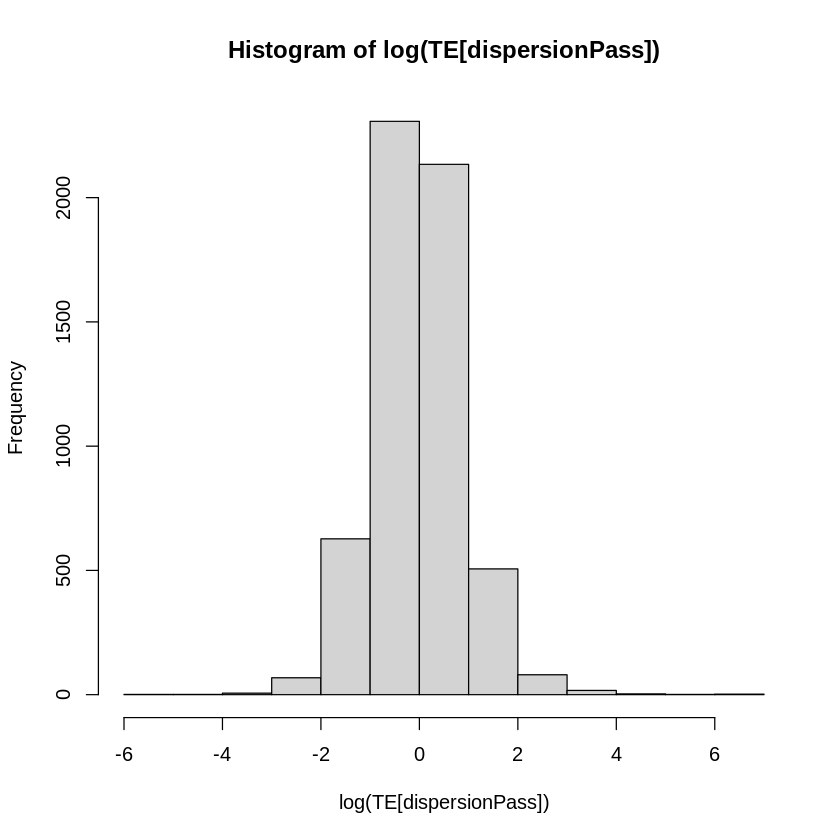

In [34]:
TE = apply(data,1,function(x) {(mean(x[1:3])+1) / (1+mean(x[7:9]))})
hist(log(TE))
hist(log(TE[!countsPass %in% dispersionPass]))
hist(log(TE[countsPass]))
hist(log(TE[dispersionPass]))

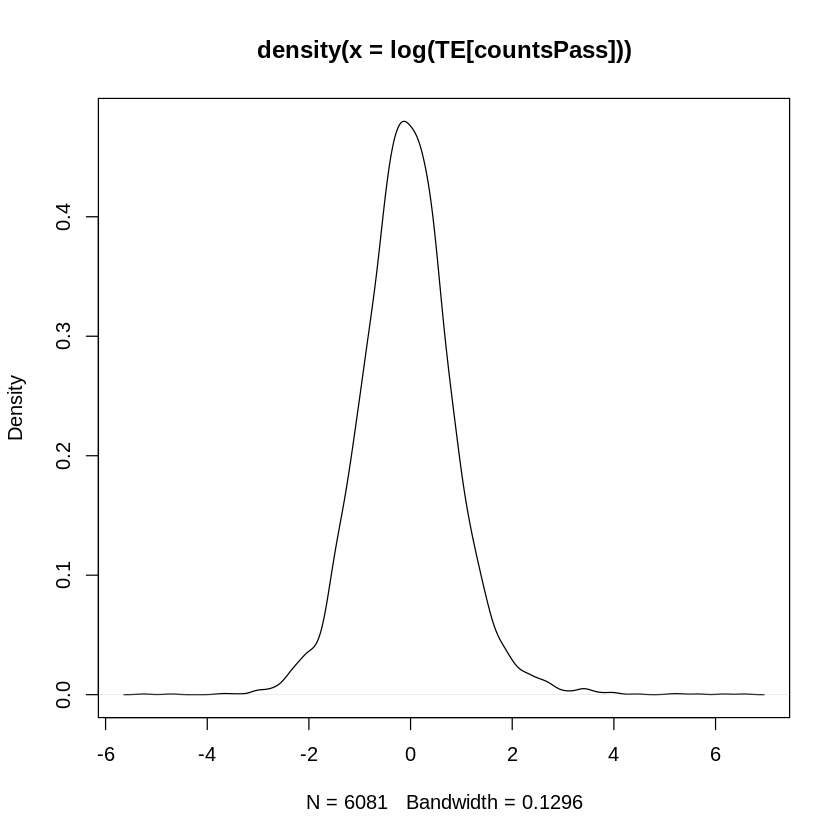

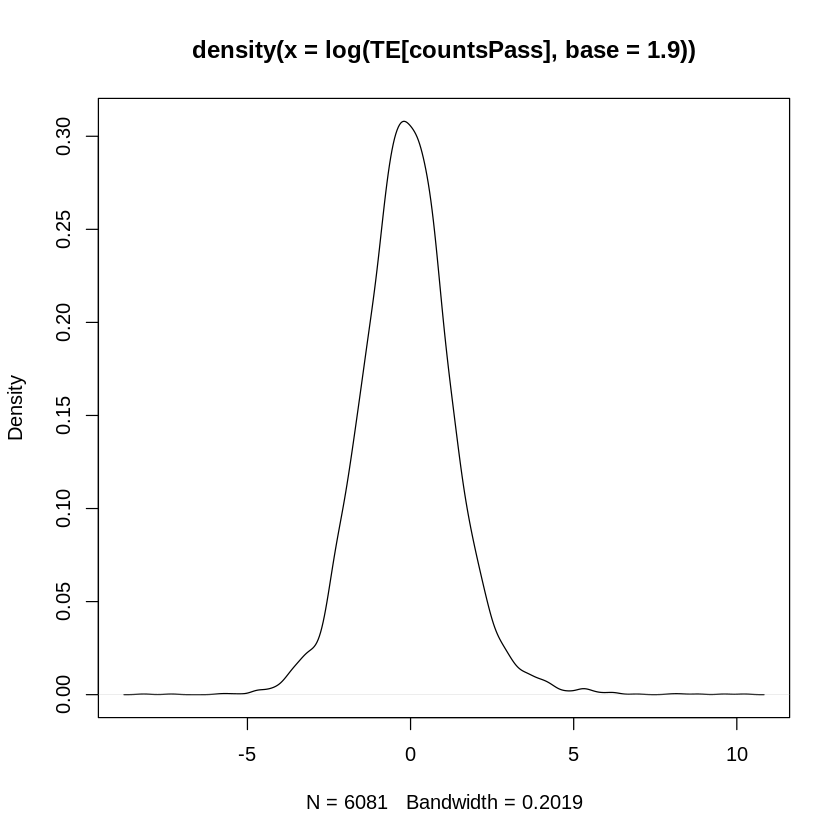

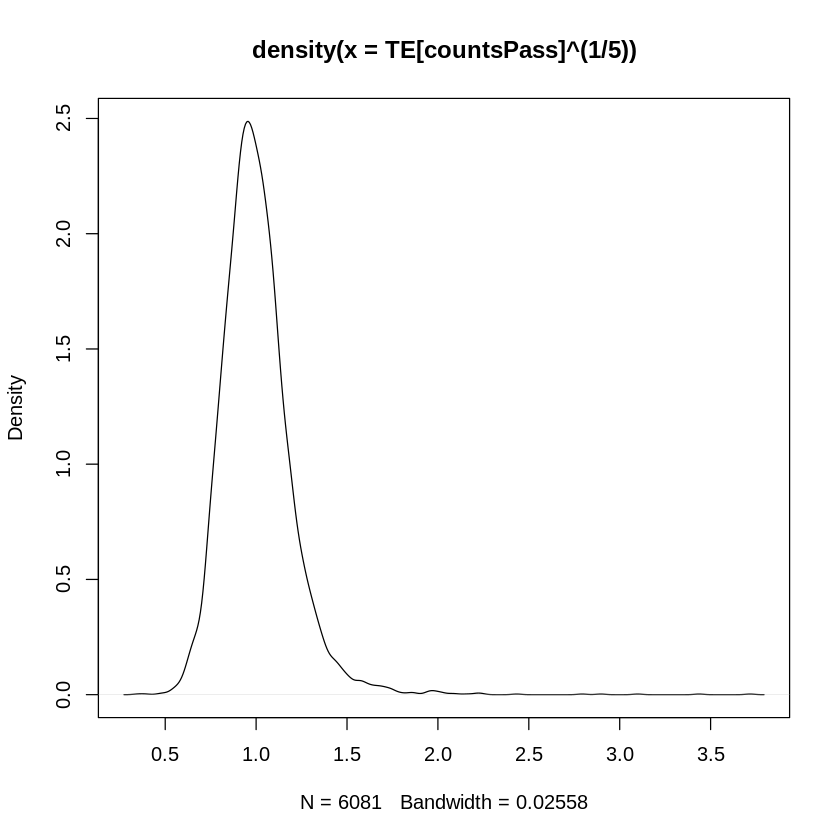

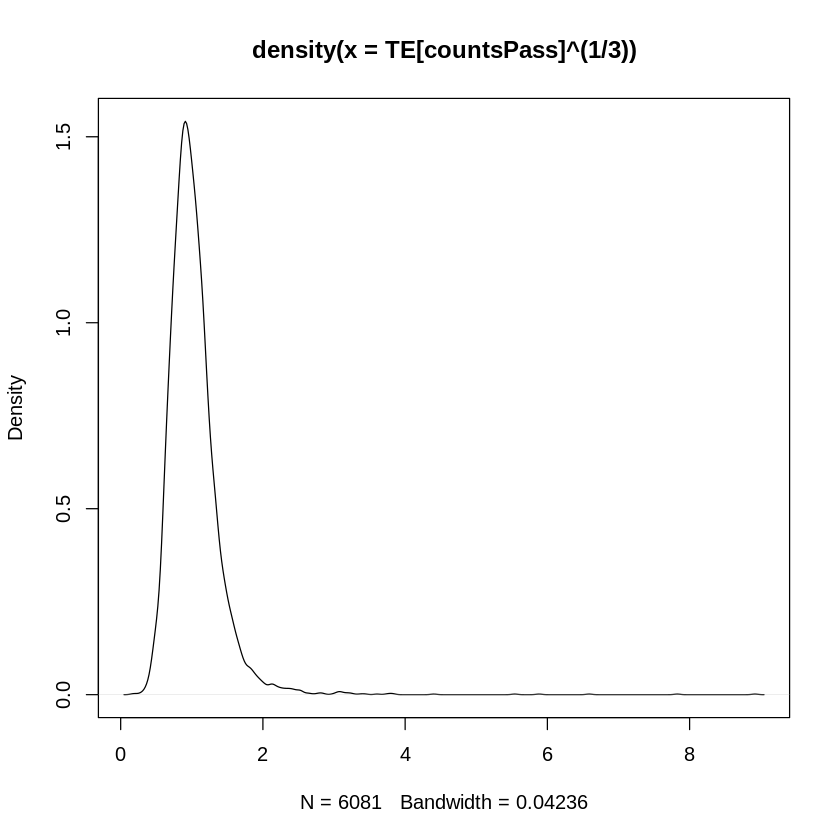

In [48]:
plot(density(log(TE[countsPass])))
plot(density(log(TE[countsPass],base = 1.9)))
plot(density(TE[countsPass]**(1/5)))
plot(density(TE[countsPass]**(1/3)))

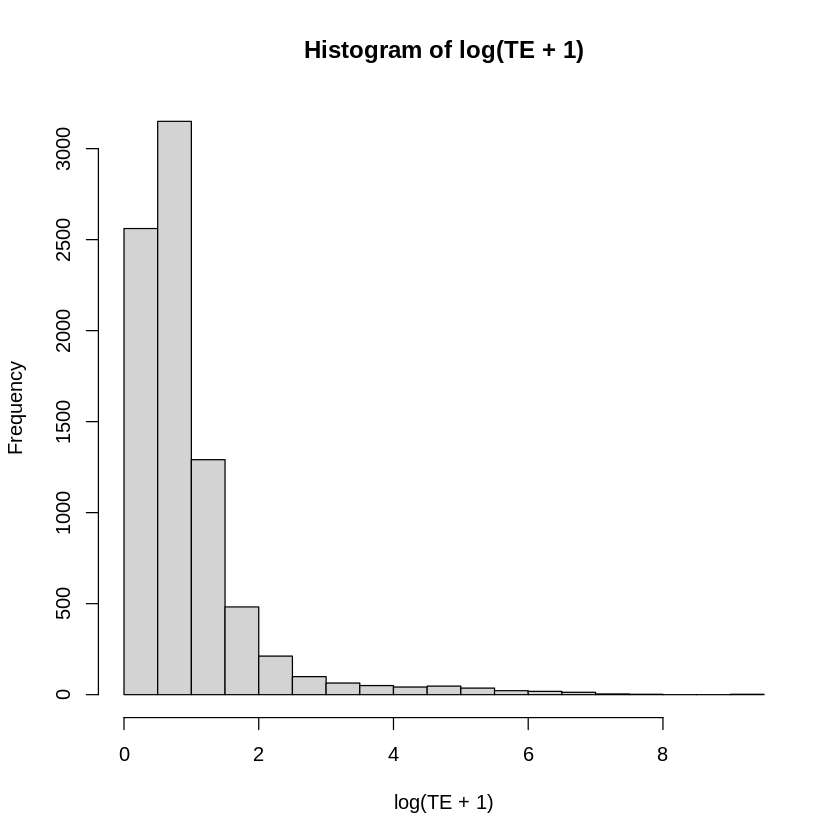

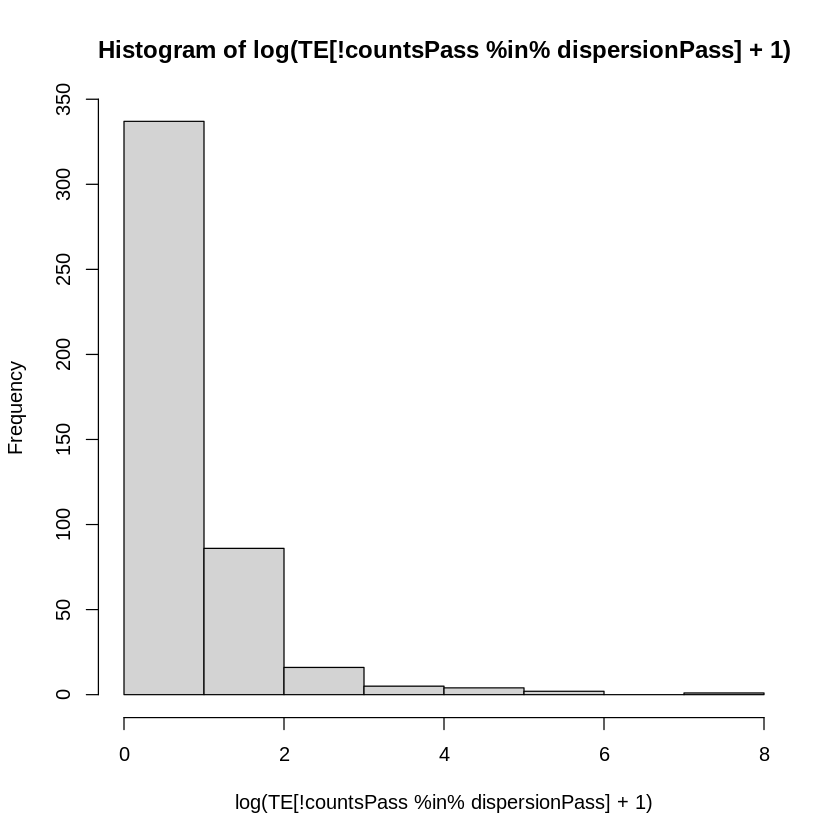

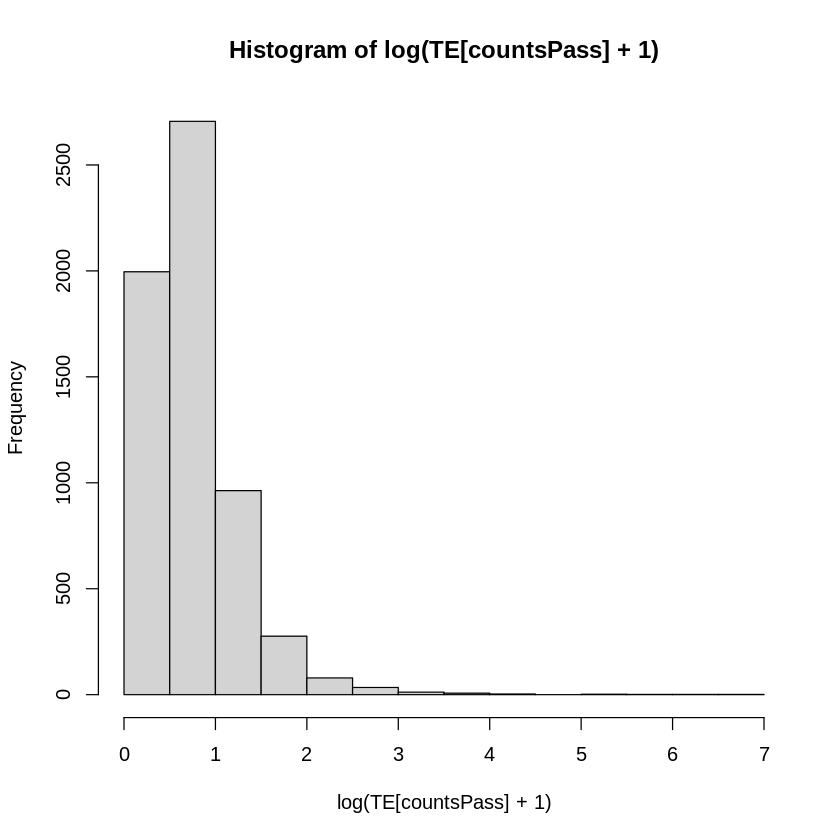

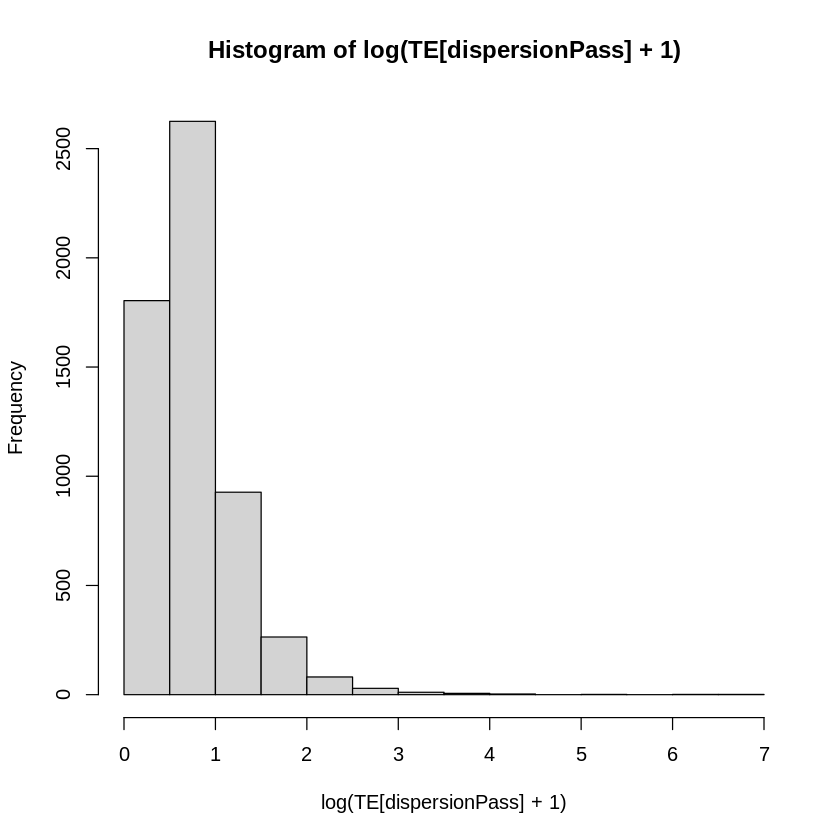

In [35]:
hist(log(TE+1))
hist(log(TE[!countsPass %in% dispersionPass]+1))
hist(log(TE[countsPass]+1))
hist(log(TE[dispersionPass]+1))

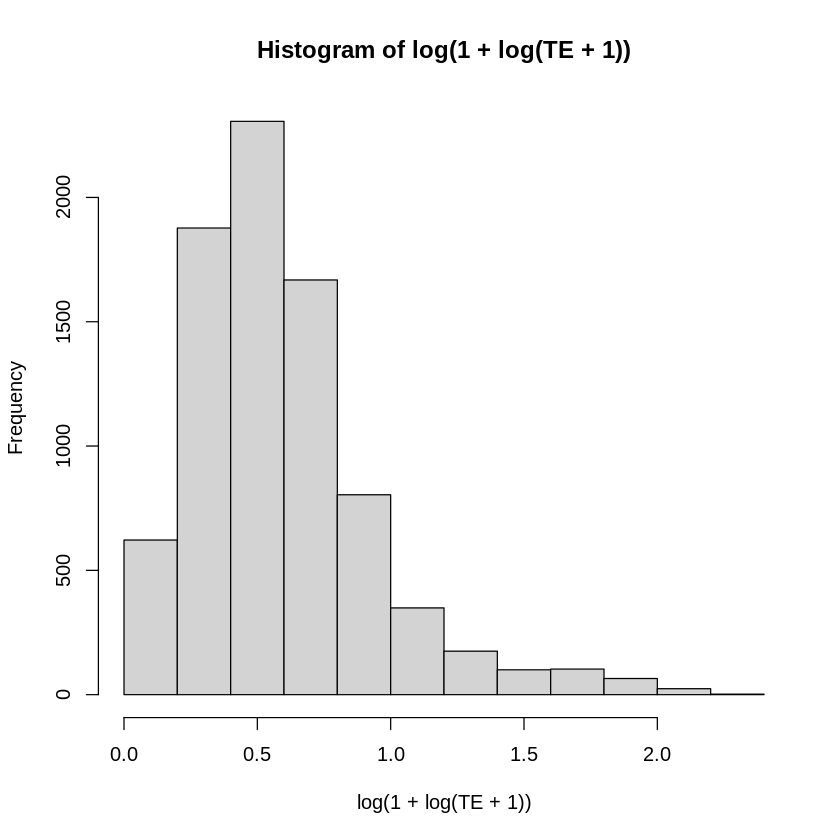

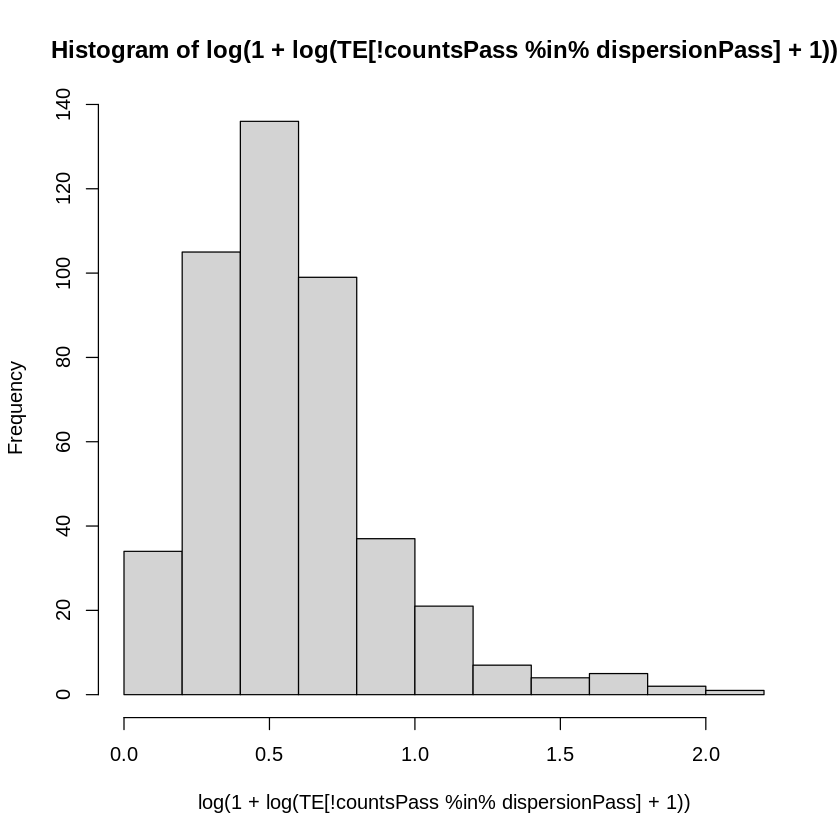

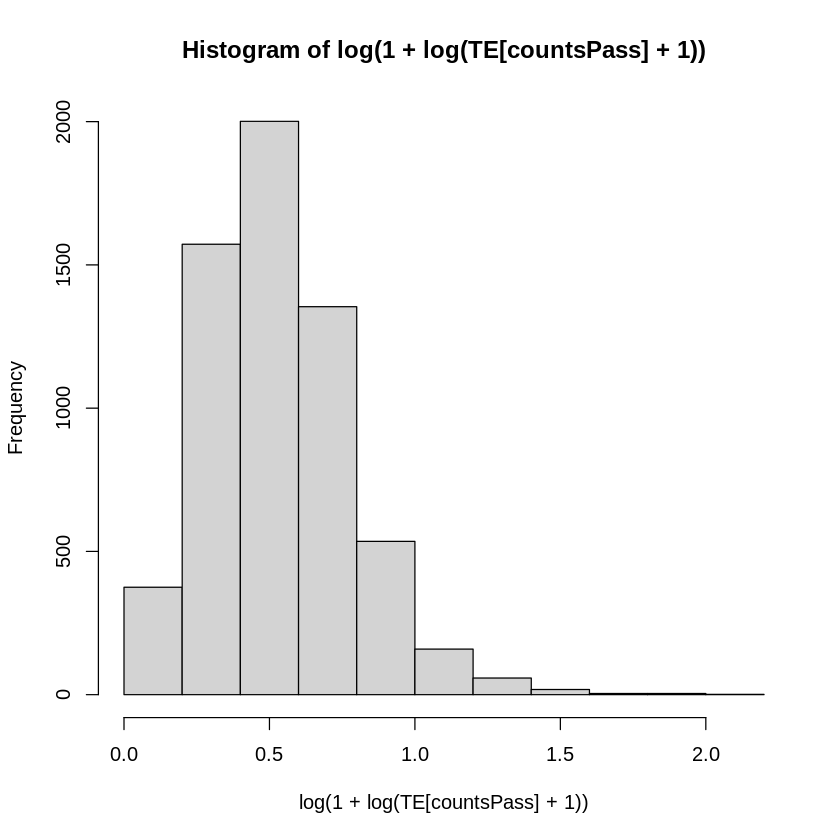

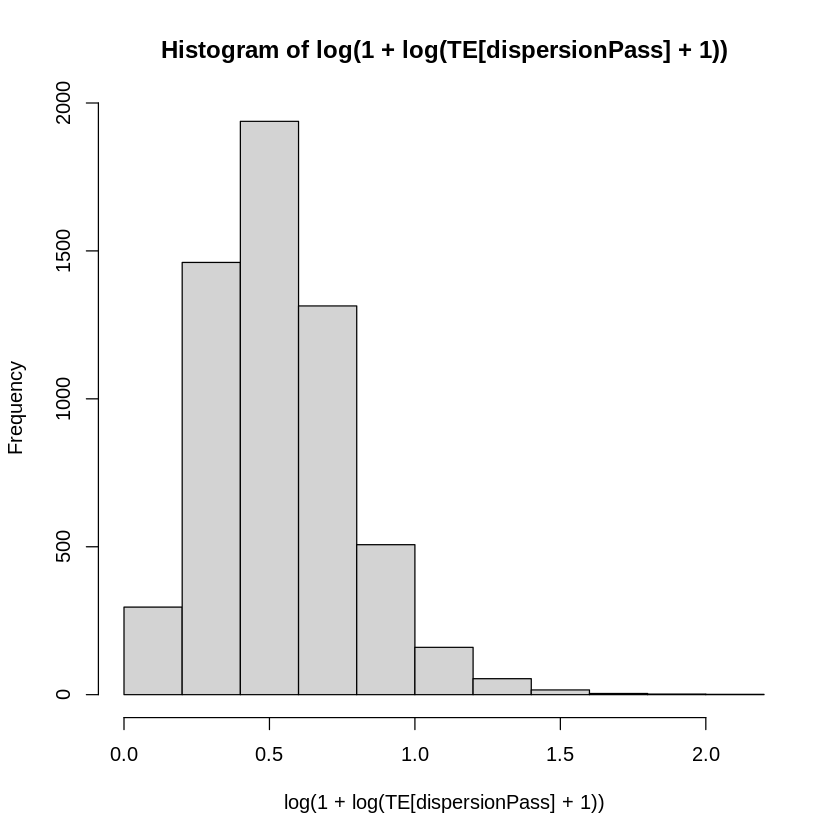

In [36]:
hist(log(1+log(TE+1)))
hist(log(1+log(TE[!countsPass %in% dispersionPass]+1)))
hist(log(1+log(TE[countsPass]+1)))
hist(log(1+log(TE[dispersionPass]+1)))

In [8]:
df = data.frame(dispRibo = dispersions(ribo),
                 dispGeneEstRibo = mcols(ribo)$dispGeneEst,
                 dispRna = dispersions(rna),
                 dispGeneEstRna = mcols(rna)$dispGeneEst,
                 row.names = rownames(ribo))

df[c('FBgn0000636','FBgn0001114','FBgn0001247','FBgn0001256'),]
df[c('FBgn0000015','FBgn0000039','FBgn0000047','FBgn0000108'),]
counts[c('FBgn0000636','FBgn0001114','FBgn0001247','FBgn0001256'),]
counts[c('FBgn0000015','FBgn0000039','FBgn0000047','FBgn0000108'),]

,dispRibo,dispGeneEstRibo,dispRna,dispGeneEstRna
,<dbl>,<dbl>,<dbl>,<dbl>
FBgn0000636,0.8046118,0.00000001,0.37881628,1.13964642
FBgn0001114,0.7311320,0.65587237,0.83018737,3.05813075
FBgn0001247,0.4698634,1.19657353,0.02144587,0.02312476
FBgn0001256,0.5208235,0.00000001,0.49023222,1.59291352


,dispRibo,dispGeneEstRibo,dispRna,dispGeneEstRna
,<dbl>,<dbl>,<dbl>,<dbl>
FBgn0000015,2.324909,0.00000001,0.3095622,0.59938215
FBgn0000039,10.000000,0.00000001,7.5904003,0.00000001
FBgn0000047,0.830779,0.29009734,1.4175079,0.00000001
FBgn0000108,1.832121,0.00000001,0.2161323,0.21355365


,RPFsRawCounts.DC7_184t_bw_star_Aligned.sortedByCoord.out.bam,RPFsRawCounts.DC8_184t_bw_star_Aligned.sortedByCoord.out.bam,RPFsRawCounts.DC9_184t_bw_star_Aligned.sortedByCoord.out.bam,mRNARawCounts.DC10_184t_star_Aligned.sortedByCoord.out.bam,mRNARawCounts.DC11_184t_star_Aligned.sortedByCoord.out.bam,mRNARawCounts.DC12_184t_star_Aligned.sortedByCoord.out.bam
,<int>,<int>,<int>,<int>,<int>,<int>
FBgn0000636,7,4,4,52,5,9
FBgn0001114,8,13,1,17,0,7
FBgn0001247,20,26,1,272,267,196
FBgn0001256,8,7,8,48,5,3


,RPFsRawCounts.DC7_184t_bw_star_Aligned.sortedByCoord.out.bam,RPFsRawCounts.DC8_184t_bw_star_Aligned.sortedByCoord.out.bam,RPFsRawCounts.DC9_184t_bw_star_Aligned.sortedByCoord.out.bam,mRNARawCounts.DC10_184t_star_Aligned.sortedByCoord.out.bam,mRNARawCounts.DC11_184t_star_Aligned.sortedByCoord.out.bam,mRNARawCounts.DC12_184t_star_Aligned.sortedByCoord.out.bam
,<int>,<int>,<int>,<int>,<int>,<int>
FBgn0000015,1,3,1,5,22,30
FBgn0000039,1,0,0,2,0,0
FBgn0000047,11,4,2,3,2,3
FBgn0000108,2,1,3,38,15,16


In [4]:
dds <- DESeq(dds)


estimating size factors



estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



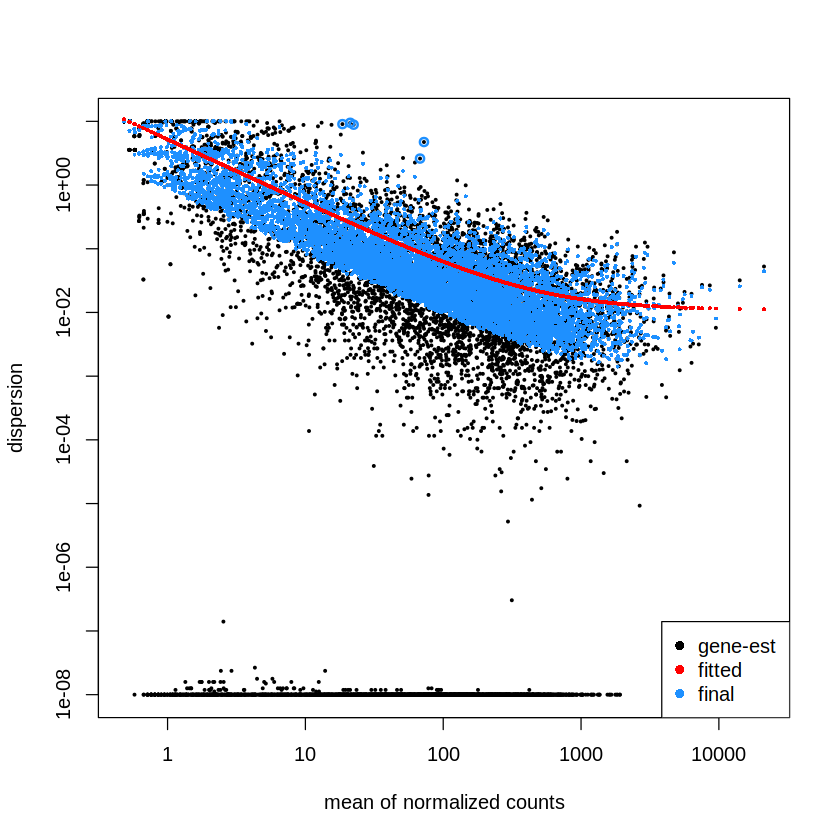

In [5]:
plotDispEsts(dds)


In [6]:
res <- results(dds)
head(res)


log2 fold change (MLE): condition rnaseq vs riboseq 
Wald test p-value: condition rnaseq vs riboseq 
DataFrame with 6 rows and 6 columns
             baseMean log2FoldChange     lfcSE       stat      pvalue
            <numeric>      <numeric> <numeric>  <numeric>   <numeric>
FBgn0000008  97.87061      1.5388273  0.255386  6.0255049 1.68583e-09
FBgn0000014  14.92800     -0.8928737  0.513445 -1.7389864 8.20372e-02
FBgn0000015   5.47884     -0.0729270  1.106614 -0.0659010 9.47457e-01
FBgn0000017 828.91359     -0.1999105  0.109150 -1.8315181 6.70232e-02
FBgn0000018  43.00633     -0.0329022  0.334756 -0.0982873 9.21704e-01
FBgn0000024   1.16512      0.1546772  3.678566  0.0420482 9.66460e-01
                   padj
              <numeric>
FBgn0000008 8.70333e-09
FBgn0000014 1.30193e-01
FBgn0000015 9.63855e-01
FBgn0000017 1.08736e-01
FBgn0000018 9.43463e-01
FBgn0000024 9.77797e-01

In [7]:
# get dispersion estimates
disp <- dispersions(dds)
disp

[1]  0.012444921  0.091344822  0.552529899  0.006460966  0.038546634
   [6]  8.650182210  0.007136320  7.629669762  0.004033934  0.021489387
  [11]  0.678384756  0.743365377  0.040256541  0.258473561  0.038918847
  [16]  0.013909478  0.322022857  2.605052017  0.019735528  0.017026814
  [21]  0.002874769  0.125306803  0.774207689  0.043847246  0.026004495
  [26]  0.152237279  0.010672303  0.044356570  0.312976843  0.034979130
  [31]  0.082555530  0.030798402  0.016333710  0.005204106  0.008202531
  [36]  0.034037982  0.033583187  0.012671982  0.019198104  0.007351516
  [41]  0.090217608  0.201003694  0.585704564  0.043727875  0.005375171
  [46]  0.007722762  0.008123166  0.022697250  0.018241293  0.440666192
  [51]  0.001870164  0.003194794  0.097923909  0.078000906  0.057617362
  [56]  0.006918747  0.066142510  0.161830020  0.007193266  0.534555805
  [61]  0.070372948  0.026783058  0.056583957  0.018748384  0.027381511
  [66]  0.010142517  0.061887595  0.021099394  0.012059612  0.015622621
  [71]  0.002962901  0.514164450  0.022319475  0.025986941  0.004403073
  [76]  0.965500616  0.006154567  0.013804325  0.013969309  0.003165856
  [81]  0.015340648  0.007811523  0.192827724  0.017530263  0.028852680
  [86]  0.016622818  0.044552411  0.203317768  0.010475214  2.774697163
  [91]  4.731260236  0.064615027  0.002658180  0.034553590  0.009115931
  [96]  0.005204147  0.076670391  0.105572655  0.194884578  0.006044822
 [101]  0.003606042  0.027732950  0.018559194  0.011464072  0.002438969
 [106]  1.983103140  0.014183986  0.329041986  0.015025319  0.051611466
 [111]  1.902921571  0.154313964  0.031915591  0.150179665  0.012797103
 [116]  0.033038767  0.303965262  0.118278613  0.076434830  0.054548320
 [121]  0.056348965  0.016223279  0.017723360  0.044231967  0.009607454
 [126]  0.021994517  0.008103624  0.019152991  0.033530290  0.006044005
 [131]  0.035743223  0.362191390  0.022814827  0.052032990  0.176805368
 [136]  0.012252852  0.931903897  0.202606190  0.006750811  0.251752917
 [141]  0.183411348  0.004938817  0.043217733  0.055848971  0.016787092
 [146]  0.290963206  0.116103507  0.004455899  0.027682426  0.010923576
 [151]  0.059074161  0.031039677  0.207774066  0.146993557  0.622928227
 [156]  0.193034724  0.080683365  0.015609151  0.009307261  0.016101572
 [161]  0.012412648  0.005145647  0.016240364  0.081180109  0.019697982
 [166]  0.101740336  0.126685003  0.287798077  0.004300528  0.057275894
 [171]  0.299897219  0.006665780  0.011168557  0.210555545  0.003727889
 [176]  0.015658091  0.019974732  0.037707935  0.003521645  0.069173088
 [181]  0.007758041  0.051258587  0.012826961  0.012207763  0.010209413
 [186]  1.122556685  0.012348933  0.007091821  0.179252189  0.012241379
 [191]  0.028136046  0.008335216  0.015320006  0.782757270  0.003701244
 [196]  0.023711534  1.295652041  0.029993735  0.146471568  0.148725093
 [201]  0.003880803  0.087698875  0.006545853  0.016283378  0.034696349
 [206]  0.007156890  0.066056143  0.018023488  0.009521774  0.004420119
 [211]  0.006302694  0.004383912  0.071532773  0.007405473  0.066253973
 [216]  0.029947627  0.026529123  0.023052699  3.209882038  0.363027349
 [221]  0.132937431  0.026137697  0.050830352  0.298068303  0.070470284
 [226]  0.214191734  1.683631758  0.489721791  0.752491408  0.751663574
 [231]  0.332340360  0.880184087  0.024103421  0.083679845  1.356340454
 [236]  0.076919287  0.462472190  0.041661086  0.006277444  0.002930918
 [241]  1.226516358  0.004519947  0.049252320  0.271712819  0.036112023
 [246]  0.041195782  0.008364766  0.015551347  0.006653276  0.024532210
 [251]  0.020219981  0.031722167  0.012009431  0.019541980  0.012900784
 [256]  0.048924051  0.036260671  0.201038839  0.018448860  0.023650712
 [261]  0.353068240  0.009615218  0.114811478  0.016899407  0.008395581
 [266]  0.695595790  0.016042585  0.031801609  0.015897961  0.014509281
 [271]  0.003804143  0.041626915  0.016478409  0.173617818  0.004965242
 [276]  0.058075115  0.038193240  0.0137997

In [9]:
mcols(dds)$dispFit

[1]  0.06401043  0.35865204  0.95826770  0.01724213  0.13166158  4.46549837
   [7]  0.02423321  9.05368685  0.01170686  0.01809926  0.11021730  0.34056474
  [13]  0.04815736  0.57154786  0.03172674  0.05444500  0.36491756  0.98899773
  [19]  0.05462098  0.07750988  0.02049609  0.05750512  0.94413879  0.07790784
  [25]  0.03477842  0.12796023  0.02325317  0.01319991  0.76862611  0.05817485
  [31]  0.01382806  0.05653832  0.03067075  0.01337605  0.02509426  0.04578563
  [37]  0.02005562  0.03786733  0.04387075  0.01371669  0.32091648  0.35858481
  [43]  1.07735611  0.05940087  0.02046860  0.02094561  0.02558666  0.05411828
  [49]  0.01650536  0.14212103  0.01724732  0.01511641  0.19450982  0.22898060
  [55]  0.02134064  0.01452503  0.24234325  0.30378376  0.01551761  2.30224706
  [61]  0.30082994  0.03581742  0.04952824  0.01497028  0.01986392  0.01419564
  [67]  0.07212465  0.06386185  0.03494422  0.05377293  0.01933476  2.42865981
  [73]  0.01390364  0.06138552  0.01683324  0.12078624  0.01464688  0.01525133
  [79]  0.02248233  0.02095975  0.02726874  0.01502348  0.58295898  0.06209408
  [85]  0.07593916  0.05665518  0.05244928  0.36572243  0.01934969  0.63652078
  [91]  0.08258948  0.05026653  0.01929550  0.03023244  0.01960021  0.02070472
  [97]  0.03017329  0.19547021  0.25819514  0.01199264  0.01180005  0.05834751
 [103]  0.01378369  0.01969628  0.01332747  4.90168179  0.03960715  0.63569878
 [109]  0.02948030  0.20948590  0.36028307  0.04048673  0.05492333  0.40024721
 [115]  0.01995745  0.04982305  0.36186824  0.03019570  0.06110640  0.26529378
 [121]  0.15175483  0.02634545  0.03279628  0.02555456  0.05687339  0.03950354
 [127]  0.01398501  0.04783578  0.04596268  0.02318180  0.01680329  1.31935614
 [133]  0.01158484  0.03414255  0.39136131  0.02908032  5.47951236  0.35520601
 [139]  0.04534615  0.33815310  0.41767989  0.02305737  0.01467545  0.01431195
 [145]  0.05102383  1.40524906  0.18962468  0.02043610  0.04504596  0.03120237
 [151]  0.19166432  0.11982637  0.67008002  0.20150091  0.46538594  0.21593859
 [157]  0.16832830  0.02369760  0.02755310  0.02351912  0.03541413  0.01903026
 [163]  0.01460319  0.39489968  0.03552015  0.25624225  0.04188179  0.82704777
 [169]  0.01502377  0.07971695  0.12331869  0.01495394  0.04296275  0.15070982
 [175]  0.02163092  0.01585561  0.02286936  0.01695505  0.02143437  0.02388000
 [181]  0.01887883  0.12274601  0.01462644  0.01777010  0.03415724  0.42241684
 [187]  0.02767843  0.02477942  0.16232141  0.03196106  0.06639092  0.03185966
 [193]  0.05198738  0.39586605  0.01607455  0.01935095  3.92694903  0.04052828
 [199]  0.17300574  0.23872912  0.01837992  0.02555948  0.04213602  0.02045862
 [205]  0.10275274  0.02407133  0.10745190  0.01180051  0.04021460  0.02133168
 [211]  0.01430362  0.01325604  0.02525933  0.02126672  0.16524832  0.05319714
 [217]  0.02047955  0.01580361  2.35717549  0.42619451  0.36694642  0.01228927
 [223]  0.04357593  0.09987303  0.02486240  0.54782074  0.47832191  0.12314930
 [229]  3.94241369  0.33692624  0.51040340  3.11691835  0.11781942  0.02998188
 [235]  6.83294442  0.40817942  1.81973885  0.17217160  0.02835653  0.01697302
 [241]  0.70086277  0.01704204  0.12418574  0.38982100  0.07423120  0.05613167
 [247]  0.03388103  0.02188201  0.02065323  0.02873988  0.02372935  0.02924516
 [253]  0.01984182  0.02828910  0.01355465  0.03468892  0.05402181  0.16812815
 [259]  0.05416185  0.01857266  0.48128433  0.02365802  0.12330041  0.05108658
 [265]  0.04626942  1.50170843  0.02158892  0.03664660  0.08061045  0.05282948
 [271]  0.02263649  0.19127929  0.01618610  0.12732987  0.01600473  0.04338241
 [277]  0.02503210  0.06031564  0.01800667  0.29798031  0.49968635  0.01338240
 [283]  0.01327933  0.01974517  0.01651960  0.02039579  0.02615072  0.01499629
 [289]  0.05514176  0.04107658  0.04184814  0.03220555  0.08745644  0.03757309
 [295]  0.01809982  1.17630491  0.01422328  0.01888572  0.01379746  1.49343318
 [301]  0.01401618  0.01490535  0.14791433  0.5896849

In [23]:
print(min(disp))
print(min(mcols(dds)$dispFit))

[1] 0.001412029
[1] 0.0112251


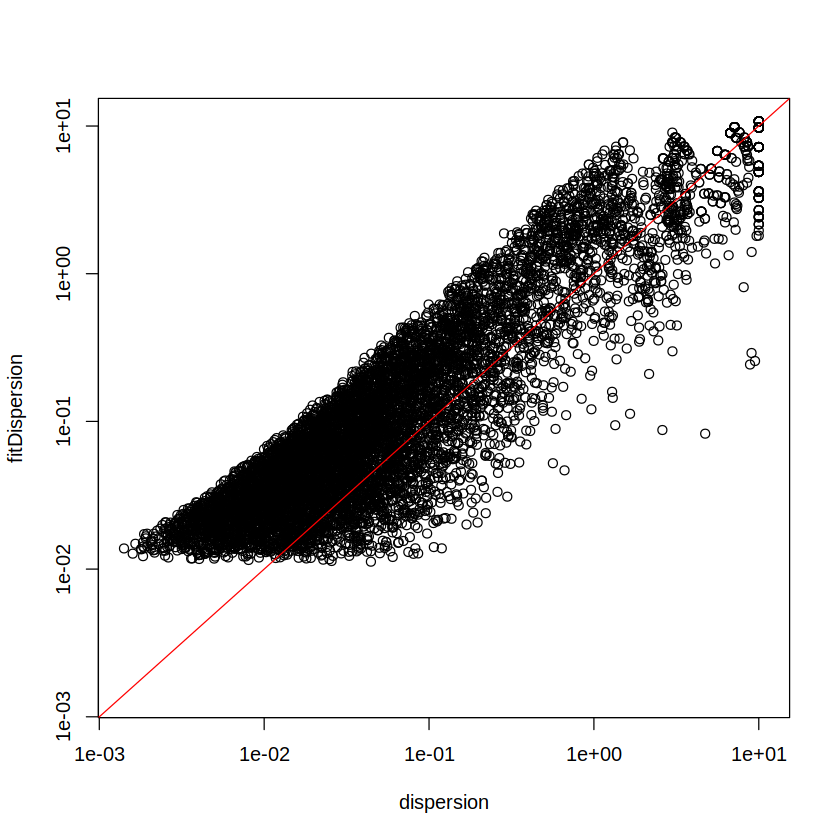

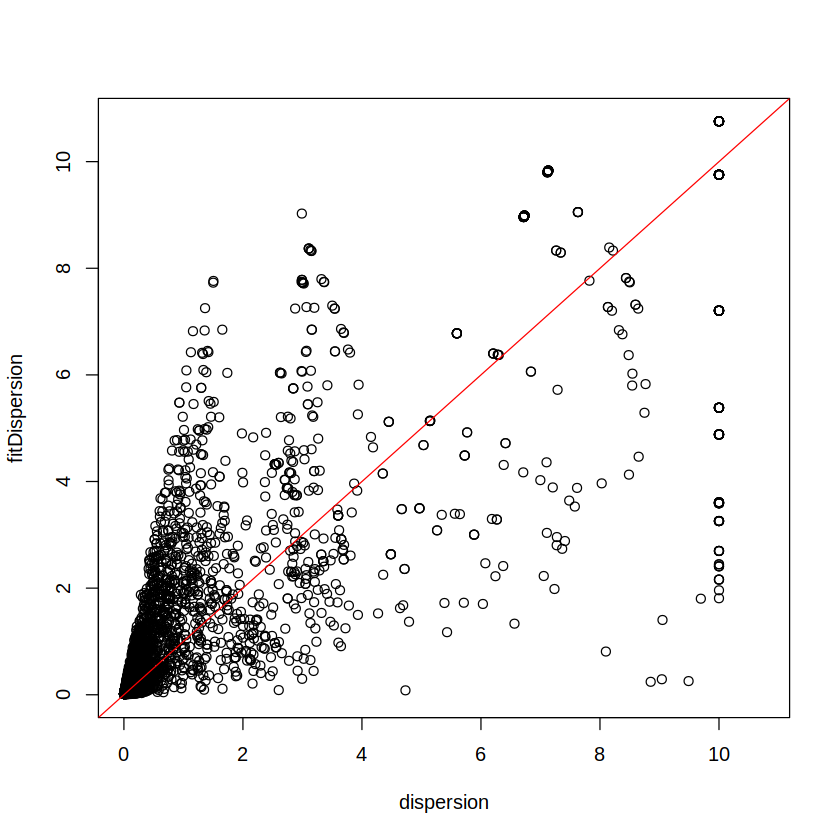

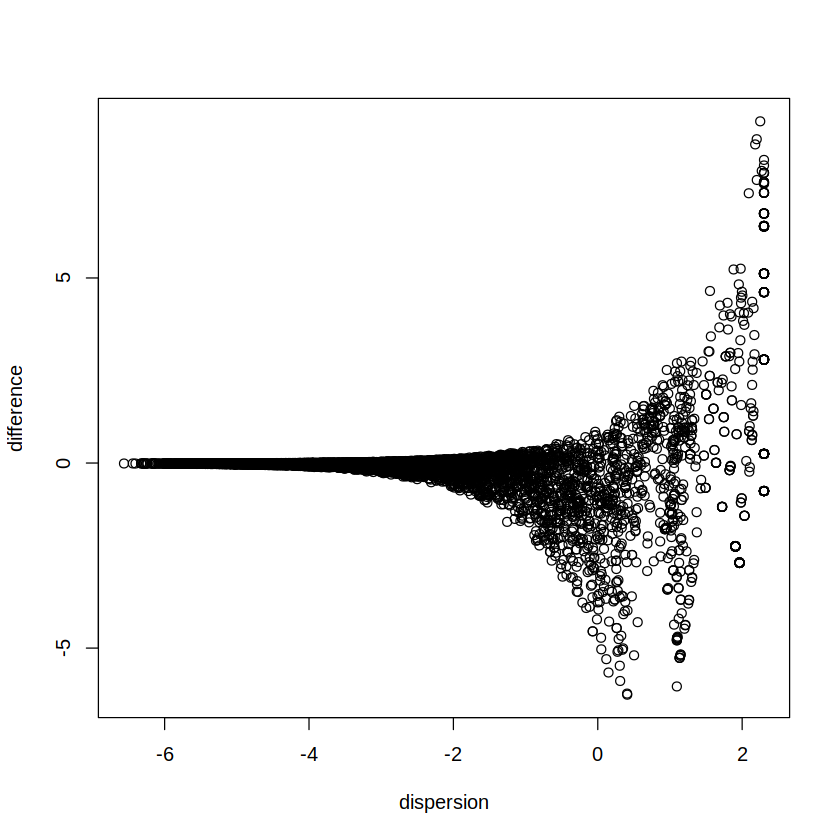

In [22]:
# Calculate the overall range
overall_range <- range(c(disp, mcols(dds)$dispFit), na.rm = TRUE)

# Set plot background to white
par(bg = "white")

plot(disp, mcols(dds)$dispFit, log="xy",
     xlab="dispersion",
     ylab="fitDispersion",
     xlim = overall_range,
     ylim = overall_range)

# Add x=y line in red
abline(a=0, b=1, col="red")

# Set plot background to white
par(bg = "white")

plot(disp, mcols(dds)$dispFit,      
xlab="dispersion",
     ylab="fitDispersion",
     xlim = overall_range,
     ylim = overall_range)

# Add x=y line in red
abline(a=0, b=1, col="red")

# Set plot background to white
par(bg = "white")

plot(log(disp), disp - mcols(dds)$dispFit,
     xlab="dispersion",
     ylab="difference")


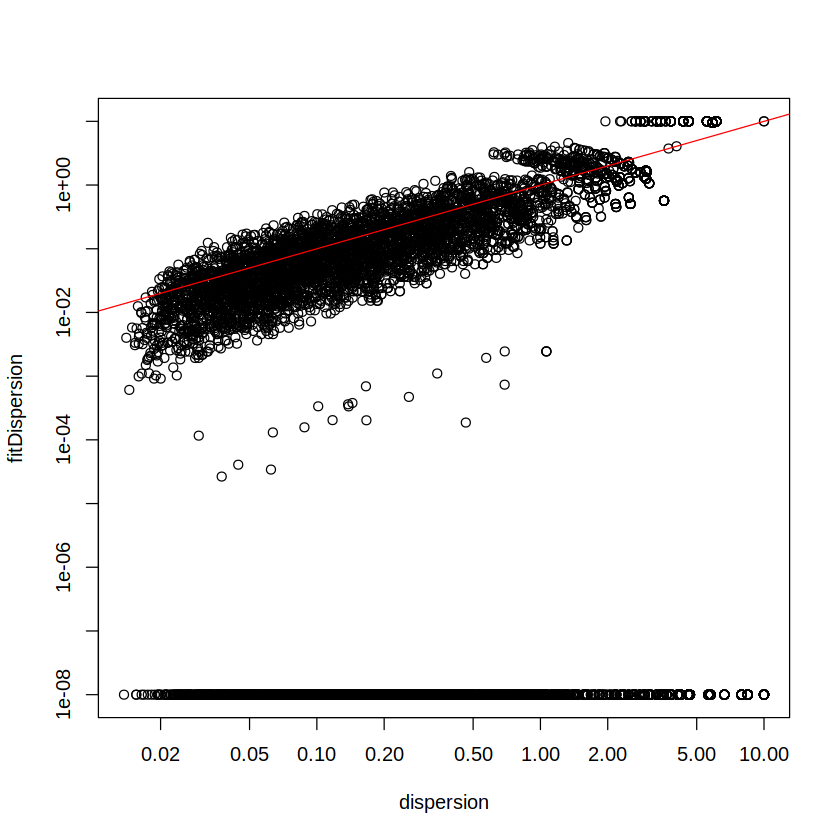

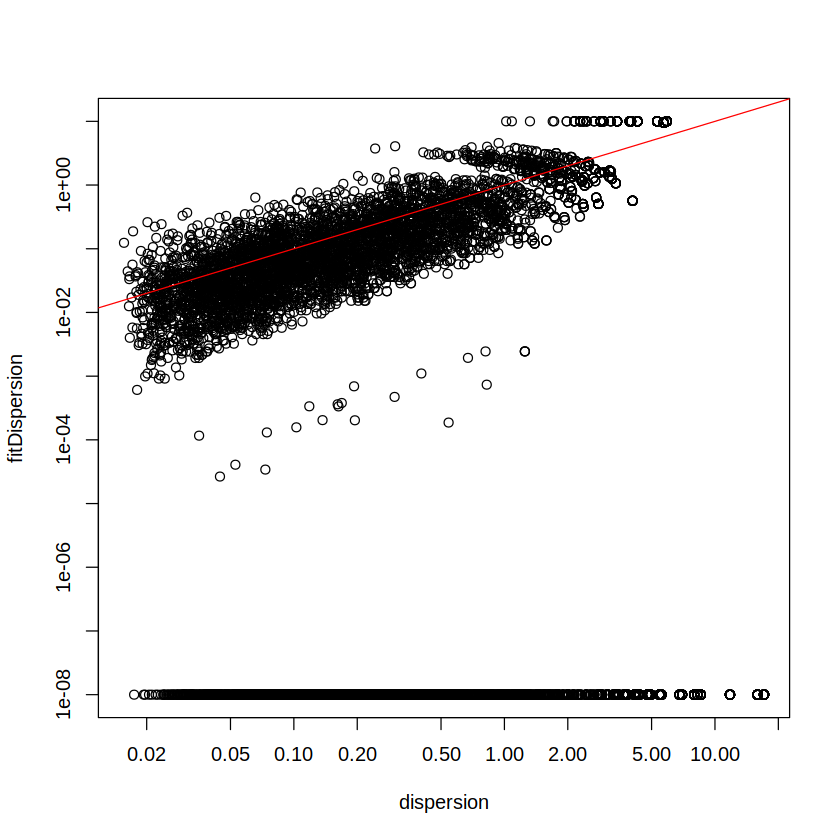

In [97]:
par(bg = "white")

plot(dispersions(ribo),rowData(ribo)[,'dispGeneEst'],
xlab="dispersion",
     ylab="fitDispersion",
log="xy")

# Add x=y line in red
abline(a=0, b=1, col="red")

par(bg = "white")

plot(mcols(ribo)$dispFit,rowData(ribo)[,'dispGeneEst'],
xlab="dispersion",
     ylab="fitDispersion",
log="xy")

# Add x=y line in red
abline(a=0, b=1, col="red")

In [17]:
disp - mcols(dds)$dispFit

[1] -5.156551e-02 -2.673072e-01 -4.057378e-01 -1.078116e-02 -9.311495e-02
   [6]  4.184684e+00 -1.709689e-02 -1.424017e+00 -7.672927e-03  3.390122e-03
  [11]  5.681675e-01  4.028006e-01 -7.900815e-03 -3.130743e-01  7.192106e-03
  [16] -4.053553e-02 -4.289470e-02  1.616054e+00 -3.488545e-02 -6.048307e-02
  [21] -1.762132e-02  6.780168e-02 -1.699311e-01 -3.406060e-02 -8.773926e-03
  [26]  2.427705e-02 -1.258087e-02  3.115666e-02 -4.556493e-01 -2.319572e-02
  [31]  6.872747e-02 -2.573992e-02 -1.433704e-02 -8.171946e-03 -1.689173e-02
  [36] -1.174765e-02  1.352757e-02 -2.519535e-02 -2.467265e-02 -6.365176e-03
  [41] -2.306989e-01 -1.575811e-01 -4.916516e-01 -1.567299e-02 -1.509343e-02
  [46] -1.322284e-02 -1.746350e-02 -3.142103e-02  1.735935e-03  2.985452e-01
  [51] -1.537715e-02 -1.192161e-02 -9.658591e-02 -1.509797e-01  3.627672e-02
  [56] -7.606278e-03 -1.762007e-01 -1.419537e-01 -8.324339e-03 -1.767691e+00
  [61] -2.304570e-01 -9.034359e-03  7.055715e-03  3.778103e-03  7.517589e-03
  [66] -4.053124e-03 -1.023705e-02 -4.276246e-02 -2.288460e-02 -3.815031e-02
  [71] -1.637186e-02 -1.914495e+00  8.415840e-03 -3.539858e-02 -1.243017e-02
  [76]  8.447144e-01 -8.492311e-03 -1.447005e-03 -8.513021e-03 -1.779389e-02
  [81] -1.192809e-02 -7.211961e-03 -3.901313e-01 -4.456382e-02 -4.708648e-02
  [86] -4.003236e-02 -7.896872e-03 -1.624047e-01 -8.874477e-03  2.138176e+00
  [91]  4.648671e+00  1.434850e-02 -1.663732e-02  4.321151e-03 -1.048428e-02
  [96] -1.550057e-02  4.649710e-02 -8.989755e-02 -6.331056e-02 -5.947815e-03
 [101] -8.194012e-03 -3.061456e-02  4.775500e-03 -8.232207e-03 -1.088850e-02
 [106] -2.918579e+00 -2.542316e-02 -3.066568e-01 -1.445498e-02 -1.578744e-01
 [111]  1.542639e+00  1.138272e-01 -2.300774e-02 -2.500675e-01 -7.160351e-03
 [116] -1.678428e-02 -5.790298e-02  8.808291e-02  1.532843e-02 -2.107455e-01
 [121] -9.540587e-02 -1.012217e-02 -1.507292e-02  1.867740e-02 -4.726594e-02
 [126] -1.750902e-02 -5.881386e-03 -2.868279e-02 -1.243238e-02 -1.713779e-02
 [131]  1.893993e-02 -9.571647e-01  1.122999e-02  1.789044e-02 -2.145559e-01
 [136] -1.682746e-02 -4.547608e+00 -1.525998e-01 -3.859534e-02 -8.640018e-02
 [141] -2.342685e-01 -1.811855e-02  2.854228e-02  4.153703e-02 -3.423674e-02
 [146] -1.114286e+00 -7.352118e-02 -1.598020e-02 -1.736353e-02 -2.027880e-02
 [151] -1.325902e-01 -8.878669e-02 -4.623060e-01 -5.450736e-02  1.575423e-01
 [156] -2.290387e-02 -8.764493e-02 -8.088450e-03 -1.824584e-02 -7.417553e-03
 [161] -2.300149e-02 -1.388462e-02  1.637178e-03 -3.137196e-01 -1.582217e-02
 [166] -1.545019e-01  8.480322e-02 -5.392497e-01 -1.072325e-02 -2.244105e-02
 [171]  1.765785e-01 -8.288164e-03 -3.179419e-02  5.984573e-02 -1.790303e-02
 [176] -1.975178e-04 -2.894630e-03  2.075288e-02 -1.791273e-02  4.529309e-02
 [181] -1.112079e-02 -7.148742e-02 -1.799482e-03 -5.562338e-03 -2.394783e-02
 [186]  7.001398e-01 -1.532949e-02 -1.768760e-02  1.693078e-02 -1.971968e-02
 [191] -3.825488e-02 -2.352444e-02 -3.666737e-02  3.868912e-01 -1.237330e-02
 [196]  4.360580e-03 -2.631297e+00 -1.053454e-02 -2.653417e-02 -9.000403e-02
 [201] -1.449911e-02  6.213939e-02 -3.559017e-02 -4.175239e-03 -6.805639e-02
 [206] -1.691444e-02 -4.139576e-02  6.222974e-03 -3.069282e-02 -1.691156e-02
 [211] -8.000928e-03 -8.872125e-03  4.627344e-02 -1.386124e-02 -9.899434e-02
 [216] -2.324952e-02  6.049577e-03  7.249086e-03  8.527065e-01 -6.316716e-02
 [221] -2.340090e-01  1.384843e-02  7.254423e-03  1.981953e-01  4.560788e-02
 [226] -3.336290e-01  1.205310e+00  3.665725e-01 -3.189922e+00  4.147373e-01
 [231] -1.780630e-01 -2.236734e+00 -9.371600e-02  5.369797e-02 -5.476604e+00
 [236] -3.312601e-01 -1.357267e+00 -1.305105e-01 -2.207909e-02 -1.404210e-02
 [241]  5.256536e-01 -1.252209e-02 -7.493342e-02 -1.181082e-01 -3.811918e-02
 [246] -1.493589e-02 -2.551626e-02 -6.330666e-03 -1.399995e-02 -4.207668e-03
 [251] -3.509368e-03  2.477006e-03 -7.832385e-03 -8.747121e-03 -6.538655e-04
 [256]  1.423513e-02 -1.776114e-02  3.291069e-02 -3.571299e-02  5.078052e-03